# EBM SPY Triple Barrier Pipeline + Meta-Labeling — **SHORT SIDE**

Pipeline cuantitativo análogo al long-only pero para señales SHORT:

1. **Datos** — OHLCV diario de SPY + ETFs sectoriales (yfinance) + macro FRED
2. **Features** — Subconjunto reducido (ret/mom/vol) sobre SPY y los 9 sectoriales + summary cross-sectional
3. **Triple Barrier Labeling — SPY** — TP/SL = 1× vol rolling 20d; barrera vertical = 7 sesiones
4. **Uniqueness (López de Prado)** — `sample_weight` por evento = avgUniqueness sobre eventos concurrentes
5. **EBM Primario SHORT** — Predice `P(SL hit | features)` (label == −1) con walk-forward purgado
6. **EBM Secundario — Meta-Labeling** — Filtra falsos positivos del primario
7. **Backtest P&L (OOS)** — SHORT SPY (Primary, Primary+Meta) vs SPY Buy & Hold como benchmark
8. **PBO (CSCV)** — Probabilidad de Backtest Overfitting
9. **Cluster Permutation Importance**

> **OOS 2022-2026: INTOCABLE** — el modelo nunca ve estos datos durante el entrenamiento.
> **Convención de entrada**: SHORT en el OPEN de la siguiente sesión tras la señal del cierre.
> **Para short, TP = barrera inferior (precio cae)** y **SL = barrera superior (precio sube contra nosotros)**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from itertools import combinations

from sklearn.metrics import average_precision_score
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

from interpret.glassbox import ExplainableBoostingClassifier
import yfinance as yf

try:
    import pandas_datareader.data as web
    HAS_DATAREADER = True
except Exception as _e:
    HAS_DATAREADER = False
    print(f'pandas_datareader not available ({type(_e).__name__}: {_e}) — skipping FRED data')

# ── Configuration ──────────────────────────────────────────────────────────────
ETFS        = ['XLE', 'XLB', 'XLI', 'XLK', 'XLF', 'XLP', 'XLY', 'XLV', 'XLU']
BENCHMARK   = 'SPY'
ALL_TICKERS = ETFS + [BENCHMARK]

START_DATE = '2005-01-01'
OOS_START  = '2022-01-01'
END_DATE   = '2026-12-31'

# Triple barrier — entry convention: signal at close[i] → enter at OPEN[i+1]
TP_MULT    = 1.0
SL_MULT    = 1.0
VOL_WINDOW = 20
VERT_BARS  = 7

VAL_MONTHS      = 12
MIN_TRAIN_YEARS = 3

PBO_SUBPERIODS = 8
FAST_MODE      = True
SKIP_TUNING    = True

# ── Meta-labeling (López de Prado AFML Cap. 3) ────────────────────────────────
PRIM_THRESHOLD = 0.5
META_THRESHOLD = 0.4
SIZE_BY_META   = True
CALIBRATE_PRIM_THRESHOLD = False

# ── Production deployment ─────────────────────────────────────────────────────
USE_PRODUCTION_MODEL = True   # if True, live signal uses model trained on FULL history (IS+OOS)
                              # if False, uses ebm_oos (trained on IS only — keeps OOS untouched)

OUTPUT_DIR = Path('outputs_short')
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Setup complete.')

pandas_datareader not available (TypeError: deprecate_kwarg() missing 1 required positional argument: 'new_arg_name') — skipping FRED data
Setup complete.


## 1. Descarga de datos

In [2]:
# ── OHLCV ─────────────────────────────────────────────────────────────────────
print('Downloading OHLCV data from Yahoo Finance...')
raw = yf.download(ALL_TICKERS, start=START_DATE, end=END_DATE,
                  auto_adjust=True, progress=False)

close  = raw['Close'].dropna(how='all')
open_  = raw['Open'].dropna(how='all')   # NEW: opens for next-day entry
volume = raw['Volume'].dropna(how='all')
high   = raw['High'].dropna(how='all')
low    = raw['Low'].dropna(how='all')

print(f'  Shape : {close.shape}')
print(f'  Range : {close.index[0].date()} → {close.index[-1].date()}')
print(f'  Missing close:\n{close.isna().sum()}')

# ── FRED macro ─────────────────────────────────────────────────────────────────
FRED_SERIES = {
    'FEDFUNDS' : 'fed_funds_rate',
    'GS10'     : 'treasury_10y',
    'BAA10Y'   : 'baa_credit_spread',
    'CPIAUCSL' : 'cpi',
    'UNRATE'   : 'unemployment',
}

macro_frames = []
if HAS_DATAREADER:
    print('\nDownloading FRED macro data...')
    for sid, name in FRED_SERIES.items():
        try:
            s = web.DataReader(sid, 'fred', START_DATE, END_DATE)
            s.columns = [name]
            if sid in ('FEDFUNDS', 'CPIAUCSL', 'UNRATE'):
                s = s.shift(1, freq='MS')
            macro_frames.append(s)
            print(f'  ✓ {sid}')
        except Exception as e:
            print(f'  ✗ {sid}: {e}')

if macro_frames:
    macro_raw = pd.concat(macro_frames, axis=1)
    macro = macro_raw.resample('B').last().reindex(close.index, method='ffill')
    if 'fed_funds_rate' in macro.columns:
        macro['fed_funds_chg'] = macro['fed_funds_rate'].diff(21)
    if 'treasury_10y' in macro.columns:
        macro['yield_chg'] = macro['treasury_10y'].diff(21)
    if 'cpi' in macro.columns:
        macro['cpi_yoy'] = macro['cpi'].pct_change(252) * 100
else:
    macro = pd.DataFrame(index=close.index)
    print('No macro features available — continuing without them.')

print(f'\nMacro features: {list(macro.columns)}')

  Shape : (5387, 10)
  Range : 2005-01-03 → 2026-06-02
  Missing close:
Ticker
SPY    0
XLB    0
XLE    0
XLF    0
XLI    0
XLK    0
XLP    0
XLU    0
XLV    0
XLY    0
dtype: int64
No macro features available — continuing without them.

Macro features: []


## 2. Feature Engineering

In [3]:
# ── SPY rolling vol (barrier size) ────────────────────────────────────────────
spy_close    = close[BENCHMARK]
spy_open     = open_[BENCHMARK]      # NEW: SPY open prices (next-day entry)
spy_ret      = spy_close.pct_change()
spy_vol_roll = spy_ret.rolling(VOL_WINDOW).std()

# All tickers (SPY + sector ETFs) used as feature sources
all_close  = close[ALL_TICKERS]
all_ret    = all_close.pct_change()

# ── Reduced feature subset (per ticker) ───────────────────────────────────────
feature_groups = {}

for p in [5, 20, 60]:
    feature_groups[f'ret_{p}d'] = all_close.pct_change(p)

for p in [63, 252]:
    feature_groups[f'mom_{p}d'] = all_close.pct_change(p)

feature_groups['vol_20d'] = all_ret.rolling(20).std()

rs_groups = {}
for p in [20]:
    rs_groups[f'rs_spy_{p}d'] = (
        all_close[ETFS].pct_change(p).sub(spy_close.pct_change(p), axis=0)
    )

print(f'Feature groups (per ticker)        : {len(feature_groups)}')
print(f'Tickers per group                  : {len(ALL_TICKERS)}  ({ALL_TICKERS})')
print(f'Relative-strength groups (sectors) : {len(rs_groups)} × {len(ETFS)}')

Feature groups (per ticker)        : 6
Tickers per group                  : 10  (['XLE', 'XLB', 'XLI', 'XLK', 'XLF', 'XLP', 'XLY', 'XLV', 'XLU', 'SPY'])
Relative-strength groups (sectors) : 1 × 9


## 3. Resumen Cross-Sectional

En lugar de neutralizar (target SPY-único), añadimos estadísticos cross-sectional entre los 9 sectoriales por feature_group:
- **mean** — tendencia colectiva del mercado sectorial
- **std**  — dispersión sectorial (régimen de divergencia / consenso)

In [4]:
# Cross-sectional summary (mean & std across sector ETFs per date) for return/vol features
xs_summary = {}
for name, df in feature_groups.items():
    sec = df[ETFS]
    xs_summary[f'xs_mean_{name}'] = sec.mean(axis=1)
    xs_summary[f'xs_std_{name}']  = sec.std(axis=1)

# Also summary on relative-strength (already sector-only)
for name, df in rs_groups.items():
    xs_summary[f'xs_mean_{name}'] = df.mean(axis=1)
    xs_summary[f'xs_std_{name}']  = df.std(axis=1)

print(f'Cross-sectional summary features: {len(xs_summary)}')

Cross-sectional summary features: 14


## 4. Triple Barrier Labeling — SPY

Etiquetas computadas **solo sobre SPY**. Los ETFs sectoriales se usan exclusivamente como predictores.

- **TP** = `1 × SPY rolling 20d std`
- **SL** = `1 × SPY rolling 20d std`
- **Vertical barrier** = 7 sesiones
- Label **+1** (TP hit), **−1** (SL hit), **0** (vertical barrier)

In [5]:
def triple_barrier_label(close_arr, open_arr, barrier_arr, tp_mult, sl_mult, vert_bars, dates):
    """Triple barrier labeling — entry at open[i+1], exits evaluated on subsequent closes.

    Returns
    -------
    labels        : ndarray  — 1 (TP), -1 (SL), 0 (vertical)
    event_ends    : ndarray of datetime64  — date of exit barrier hit
    bars_to       : ndarray  — sessions from signal to barrier (1..vert_bars)
    entry_prices  : ndarray  — open price at i+1 (actual fill price)
    """
    n = len(close_arr)
    labels       = np.full(n, np.nan)
    bars_to      = np.full(n, np.nan)
    entry_prices = np.full(n, np.nan)
    event_ends   = np.empty(n, dtype='datetime64[ns]')
    event_ends[:] = np.datetime64('NaT')

    for i in range(n - vert_bars):
        if np.isnan(barrier_arr[i]) or np.isnan(close_arr[i]):
            continue
        if i + 1 >= n:
            continue
        p_entry = open_arr[i + 1]
        if np.isnan(p_entry) or p_entry == 0:
            continue
        entry_prices[i] = p_entry

        tp = tp_mult * barrier_arr[i]
        sl = sl_mult * barrier_arr[i]

        # Future closes from entry day onwards
        fut_close = close_arr[i + 1: i + 1 + vert_bars]
        fut_r = (fut_close - p_entry) / p_entry
        valid = ~np.isnan(fut_r)

        tp_idx = np.where(valid & (fut_r >=  tp))[0]
        sl_idx = np.where(valid & (fut_r <= -sl))[0]

        first_tp = tp_idx[0] if len(tp_idx) else vert_bars
        first_sl = sl_idx[0] if len(sl_idx) else vert_bars

        if first_tp < first_sl:
            labels[i]     = 1
            bars_to[i]    = first_tp + 1
            event_ends[i] = np.datetime64(dates[min(i + 1 + first_tp, n - 1)])
        elif first_sl < first_tp:
            labels[i]     = -1
            bars_to[i]    = first_sl + 1
            event_ends[i] = np.datetime64(dates[min(i + 1 + first_sl, n - 1)])
        else:
            labels[i]     = 0
            bars_to[i]    = vert_bars
            event_ends[i] = np.datetime64(dates[min(i + vert_bars, n - 1)])

    return labels, event_ends, bars_to, entry_prices


print('Computing triple barrier labels for SPY (entry at next-day OPEN)...')
spy_vol_arr   = spy_vol_roll.values
spy_close_arr = spy_close.values
spy_open_arr  = spy_open.reindex(spy_close.index).values
dates_arr     = close.index

lbl, ev, bars, entry_p = triple_barrier_label(
    spy_close_arr, spy_open_arr, spy_vol_arr,
    tp_mult=TP_MULT, sl_mult=SL_MULT,
    vert_bars=VERT_BARS, dates=dates_arr,
)
spy_labels      = pd.Series(lbl,     index=close.index, name='label')
spy_event_ends  = pd.Series(ev,      index=close.index, name='t1')
spy_bars_to     = pd.Series(bars,    index=close.index, name='bars_to_barrier')
spy_entry_price = pd.Series(entry_p, index=close.index, name='entry_open')

valid = ~np.isnan(lbl)
n_v   = valid.sum()
print(f'  SPY: n={n_v:,} | '
      f'TP={(lbl[valid] == 1).mean():.1%} | '
      f'SL={(lbl[valid] == -1).mean():.1%} | '
      f'Vert={(lbl[valid] == 0).mean():.1%}')

print(f'\nBars to barrier (1 bar = 1 trading session; entry = open[i+1]):')
print(f'  All events     : mean={np.nanmean(bars):.2f}  median={int(np.nanmedian(bars))}  '
      f'min={int(np.nanmin(bars))}  max={int(np.nanmax(bars))}')
for k, name in [(1, 'TP'), (-1, 'SL'), (0, 'Vertical')]:
    m = (lbl == k)
    if m.sum() == 0:
        continue
    print(f'  {name:8s} (n={int(m.sum()):>5,}) : '
          f'mean={bars[m].mean():.2f}  median={int(np.median(bars[m]))}  '
          f'min={int(bars[m].min())}  max={int(bars[m].max())}')

print(f'\n  Vertical barrier = {VERT_BARS} bars (max possible bars-to-barrier)')

Computing triple barrier labels for SPY (entry at next-day OPEN)...
  SPY: n=5,360 | TP=52.2% | SL=40.5% | Vert=7.3%

Bars to barrier (1 bar = 1 trading session; entry = open[i+1]):
  All events     : mean=3.10  median=3  min=1  max=7
  TP       (n=2,797) : mean=2.89  median=3  min=1  max=7
  SL       (n=2,170) : mean=2.66  median=2  min=1  max=7
  Vertical (n=  393) : mean=7.00  median=7  min=7  max=7

  Vertical barrier = 7 bars (max possible bars-to-barrier)


## 4b. Uniqueness (López de Prado — AFML Cap. 4)

Las etiquetas triple-barrier se solapan en el tiempo (cada evento dura hasta `event_end`). Eventos concurrentes comparten información ⇒ ponderar por **average uniqueness**:

- `c_t` = número de eventos vivos en barra t
- `u_{i,t}` = 1/c_t si el evento i está vivo en t, 0 si no
- **sample_weight_i** = media de `u_{i,t}` sobre [t0_i, t1_i]

Estos pesos se pasan a `EBM.fit(sample_weight=...)` y a las métricas.

In [6]:
def num_co_events(close_idx, t1):
    """
    For each bar, number of concurrent (i.e. still-open) triple-barrier events.

    Parameters
    ----------
    close_idx : DatetimeIndex — full price index
    t1        : Series        — event start (index) → event end (value)

    Returns
    -------
    Series indexed by close_idx[first_event : last_event_end].
    """
    t1 = t1.dropna().copy()
    t1 = t1.clip(upper=close_idx[-1])

    first = t1.index.min()
    last  = pd.Timestamp(t1.max())
    span  = close_idx[(close_idx >= first) & (close_idx <= last)]

    count = pd.Series(0, index=span)
    for t_in, t_out in t1.items():
        count.loc[t_in:t_out] += 1
    return count


def avg_uniqueness(t1, co_events):
    """Average uniqueness per event (1 / concurrent count averaged over event life)."""
    weight = pd.Series(index=t1.dropna().index, dtype=float)
    for t_in, t_out in t1.dropna().items():
        weight.loc[t_in] = (1.0 / co_events.loc[t_in:t_out]).mean()
    return weight


# Compute over all valid SPY events
ev_valid = spy_event_ends.dropna()
co_ev    = num_co_events(close.index, ev_valid)
uniq_w   = avg_uniqueness(ev_valid, co_ev)

print(f'Concurrent events per bar  : min={int(co_ev.min())}  '
      f'mean={co_ev.mean():.2f}  max={int(co_ev.max())}')
print(f'Avg uniqueness  per event  : min={uniq_w.min():.3f}  '
      f'mean={uniq_w.mean():.3f}  max={uniq_w.max():.3f}')

Concurrent events per bar  : min=1  mean=4.10  max=8
Avg uniqueness  per event  : min=0.125  mean=0.259  max=0.800


## 5. Construcción del Dataset y Walk-Forward Splits

Una fila por fecha de señal SPY. Features = per-ticker (SPY + 9 sectoriales) + summary cross-sectional + macro. Walk-forward expanding window con purging por `event_end`.

In [7]:
def build_feature_matrix(tickers, feature_groups, rs_groups, xs_summary, macro, dates):
    """Wide feature matrix, one row per date. Columns = {ticker}_{feat} + xs_* + macro."""
    frames = []
    for name, df in feature_groups.items():
        for tk in tickers:
            if tk in df.columns:
                frames.append(df[tk].rename(f'{tk}_{name}'))
    for name, df in rs_groups.items():
        for tk in df.columns:
            frames.append(df[tk].rename(f'{tk}_{name}'))
    for col_name, s in xs_summary.items():
        frames.append(s.rename(col_name))
    for col in macro.columns:
        frames.append(macro[col])

    X = pd.concat(frames, axis=1)
    return X.reindex(dates)


print('Building feature matrix (target = SPY)...')
X_full = build_feature_matrix(
    ALL_TICKERS, feature_groups, rs_groups, xs_summary, macro, close.index
)

# SHORT-SIDE Target: 1 if SPY triple barrier hit SL (bearish outcome), else 0
y_full  = (spy_labels == -1).astype(float)
ev_full = spy_event_ends

valid = spy_labels.notna() & X_full.notna().any(axis=1)
X     = X_full.loc[valid]
y     = y_full.loc[valid]
ev    = ev_full.loc[valid]

# IS / OOS split
oos_mask = X.index >= OOS_START
X_is  = X[~oos_mask].copy()
y_is  = y[~oos_mask].copy()
ev_is = ev[~oos_mask].copy()
X_oos = X[oos_mask].copy()
y_oos = y[oos_mask].copy()
ev_oos = ev[oos_mask].copy()

# Impute with IS column medians
col_medians = X_is.median()
X_is  = X_is.fillna(col_medians)
X_oos = X_oos.fillna(col_medians)

feature_names = X_is.columns.tolist()

# Uniqueness sample weights aligned to X_is / X_oos
w_is  = uniq_w.reindex(X_is.index).fillna(uniq_w.mean()).values
w_oos = uniq_w.reindex(X_oos.index).fillna(uniq_w.mean()).values

print(f'  IS  : {len(X_is):,} rows | '
      f'{X_is.index[0].date()} → {X_is.index[-1].date()} | '
      f'pos rate={y_is.mean():.1%} | '
      f'weighted pos rate={np.average(y_is.values, weights=w_is):.1%}')
print(f'  OOS : {len(X_oos):,} rows | '
      f'{X_oos.index[0].date()} → {X_oos.index[-1].date()} [UNTOUCHED]')
print(f'  Features: {len(feature_names)}')


# ── Purged Walk-Forward Expanding Window Splits ────────────────────────────────
def wf_splits(dates, event_ends, val_months, min_train_years, oos_start):
    """Purged expanding-window walk-forward splits.

    Purging: training samples with event_end >= val_start are removed.
    """
    min_cut   = dates[0] + pd.DateOffset(years=min_train_years)
    val_start = min_cut
    splits    = []

    while True:
        val_end = val_start + pd.DateOffset(months=val_months)
        if val_end > pd.Timestamp(oos_start):
            break

        tr_mask  = (dates.values < val_start) & (event_ends.values < val_start)
        val_mask = (dates.values >= val_start) & (dates.values < val_end)

        if tr_mask.sum() > 200 and val_mask.sum() > 5:
            splits.append((
                np.where(tr_mask)[0],
                np.where(val_mask)[0],
                val_start, val_end,
            ))
        val_start = val_end

    return splits


splits = wf_splits(X_is.index, ev_is, VAL_MONTHS, MIN_TRAIN_YEARS, OOS_START)
print(f'\nWalk-forward splits: {len(splits)}')
for i, (tr, val, vs, ve) in enumerate(splits[:3]):
    print(f'  Fold {i+1}: train={len(tr):,} | val={len(val):,} | {vs.date()} → {ve.date()}')
if len(splits) > 3:
    print(f'  ... ({len(splits)-3} more folds)')

Building feature matrix (target = SPY)...
  IS  : 4,260 rows | 2005-02-01 → 2021-12-31 | pos rate=40.4% | weighted pos rate=41.1%
  OOS : 1,100 rows | 2022-01-03 → 2026-05-21 [UNTOUCHED]
  Features: 83

Walk-forward splits: 13
  Fold 1: train=752 | val=252 | 2008-02-01 → 2009-02-01
  Fold 2: train=1,006 | val=251 | 2009-02-01 → 2010-02-01
  Fold 3: train=1,257 | val=253 | 2010-02-01 → 2011-02-01
  ... (10 more folds)


## 6. EBM — Optimización de Hiperparámetros (Purged Walk-Forward)

In [8]:
import time

def ap_lift(y_true, y_prob, sample_weight=None):
    """Weighted Average Precision / positive class frequency."""
    if len(np.unique(y_true)) < 2:
        return 1.0 if np.any(y_true == 1) else 0.0
    if sample_weight is None:
        freq = float(y_true.mean())
    else:
        freq = float(np.average(y_true, weights=sample_weight))
    if freq == 0:
        return 0.0
    return average_precision_score(y_true, y_prob, sample_weight=sample_weight) / freq


# ── Heuristic base params ─────────────────────────────────────────────────────
EBM_BASE = dict(
    max_bins=256, max_interaction_bins=32, interactions=10,
    outer_bags=8,  inner_bags=0, learning_rate=0.01,
    validation_size=0.15, min_samples_leaf=2, max_leaves=3,
    max_rounds=5000, early_stopping_rounds=50,
    n_jobs=-1, random_state=RANDOM_STATE,
)

EBM_FAST = dict(
    max_bins=32, max_interaction_bins=8, interactions=0,
    outer_bags=1, inner_bags=0, learning_rate=0.1,
    validation_size=0.0, min_samples_leaf=10, max_leaves=3,
    max_rounds=200, early_stopping_rounds=0,
    n_jobs=-1, random_state=RANDOM_STATE,
)

base_params = EBM_FAST if FAST_MODE else EBM_BASE

FIXED_OVERRIDE = dict(interactions=0, max_leaves=3, learning_rate=0.1, max_rounds=200)

PARAM_GRID_FULL = (
    [
        dict(interactions=3, max_leaves=3, learning_rate=0.05, max_rounds=500),
        dict(interactions=5, max_leaves=3, learning_rate=0.02, max_rounds=800),
        dict(interactions=3, max_leaves=5, learning_rate=0.05, max_rounds=500),
    ] if FAST_MODE else [
        dict(max_bins=128, interactions=5,  max_leaves=3, learning_rate=0.01),
        dict(max_bins=256, interactions=10, max_leaves=3, learning_rate=0.01),
        dict(max_bins=256, interactions=10, max_leaves=5, learning_rate=0.01),
        dict(max_bins=256, interactions=15, max_leaves=3, learning_rate=0.005),
        dict(max_bins=512, interactions=10, max_leaves=3, learning_rate=0.01),
        dict(max_bins=256, interactions=10, max_leaves=3, learning_rate=0.02),
    ]
)
PARAM_GRID = [FIXED_OVERRIDE] if SKIP_TUNING else PARAM_GRID_FULL

X_arr = X_is.values
y_arr = y_is.values
w_arr = w_is

config_fold_scores = np.full((len(PARAM_GRID), len(splits)), np.nan)

# Storage for per-fold val probabilities (needed for meta-labeling OOF dataset)
# Indexed by (config_idx, fold_idx) → (val_indices, val_probs)
fold_val_probs = {}

mode_tag = 'SKIP_TUNING' if SKIP_TUNING else ('FAST' if FAST_MODE else 'FULL')
print(f"Running {len(PARAM_GRID)} config(s) x {len(splits)} folds "
      f"({mode_tag} mode, uniqueness-weighted)...\n")

best_cfg_idx = 0
best_mean    = -np.inf

t_total = time.time()
for ci, overrides in enumerate(PARAM_GRID):
    params = {**base_params, **overrides}
    fold_scores = []

    for fi, (tr_idx, val_idx, vs, ve) in enumerate(splits):
        t0 = time.time()
        ebm = ExplainableBoostingClassifier(**params)
        ebm.fit(X_arr[tr_idx], y_arr[tr_idx], sample_weight=w_arr[tr_idx])
        val_probs = ebm.predict_proba(X_arr[val_idx])[:, 1]
        score = ap_lift(y_arr[val_idx], val_probs, sample_weight=w_arr[val_idx])
        fold_scores.append(score)
        config_fold_scores[ci, fi] = score
        fold_val_probs[(ci, fi)] = (val_idx, val_probs)
        print(f'  Fold {fi+1:>2}/{len(splits)}  {vs.date()}→{ve.date()}  '
              f'tr={len(tr_idx):>5}  val={len(val_idx):>4}  '
              f'AP-lift={score:.3f}  ({time.time()-t0:.1f}s)')

    mean_score = np.nanmean(fold_scores)
    print(f'Config {ci+1}: {overrides}  →  '
          f'AP Lift = {mean_score:.4f} ± {np.nanstd(fold_scores):.4f}')

    if mean_score > best_mean:
        best_mean    = mean_score
        best_cfg_idx = ci

best_overrides = PARAM_GRID[best_cfg_idx]
best_params    = {**base_params, **best_overrides}
print(f'\nTotal time: {time.time()-t_total:.1f}s')
print(f'Best config [{best_cfg_idx+1}]: {best_overrides}')
print(f'Best AP Lift: {best_mean:.4f}')

# ── Build OOF primary probabilities Series (aligned with X_is.index) ──────────
primary_probs_oof = pd.Series(np.nan, index=X_is.index, name='primary_prob_oof')
for fi in range(len(splits)):
    val_idx, val_probs = fold_val_probs[(best_cfg_idx, fi)]
    primary_probs_oof.iloc[val_idx] = val_probs

n_oof = primary_probs_oof.notna().sum()
print(f'\nPrimary OOF predictions stored: {n_oof:,} / {len(X_is):,} ({n_oof/len(X_is):.1%})')
print(f'  Fired (prob >= {PRIM_THRESHOLD}): {(primary_probs_oof >= PRIM_THRESHOLD).sum():,}')

if SKIP_TUNING:
    print('(SKIP_TUNING=True → PBO will be skipped; set SKIP_TUNING=False to enable.)')

Running 1 config(s) x 13 folds (SKIP_TUNING mode, uniqueness-weighted)...

  Fold  1/13  2008-02-01→2009-02-01  tr=  752  val= 252  AP-lift=1.064  (5.4s)
  Fold  2/13  2009-02-01→2010-02-01  tr= 1006  val= 251  AP-lift=0.994  (3.9s)
  Fold  3/13  2010-02-01→2011-02-01  tr= 1257  val= 253  AP-lift=0.990  (3.9s)
  Fold  4/13  2011-02-01→2012-02-01  tr= 1509  val= 252  AP-lift=1.005  (3.9s)
  Fold  5/13  2012-02-01→2013-02-01  tr= 1760  val= 251  AP-lift=1.021  (4.0s)
  Fold  6/13  2013-02-01→2014-02-01  tr= 2008  val= 252  AP-lift=1.162  (4.0s)
  Fold  7/13  2014-02-01→2015-02-01  tr= 2262  val= 251  AP-lift=1.238  (4.1s)
  Fold  8/13  2015-02-01→2016-02-01  tr= 2514  val= 251  AP-lift=1.000  (4.2s)
  Fold  9/13  2016-02-01→2017-02-01  tr= 2767  val= 253  AP-lift=0.996  (1.7s)
  Fold 10/13  2017-02-01→2018-02-01  tr= 3018  val= 252  AP-lift=0.862  (1.8s)
  Fold 11/13  2018-02-01→2019-02-01  tr= 3270  val= 251  AP-lift=0.941  (1.9s)
  Fold 12/13  2019-02-01→2020-02-01  tr= 3522  val= 252 

## 6b. Primary Threshold Calibration (Walk-Forward + CSCV)

Calibramos `PRIM_THRESHOLD` sin tocar OOS, usando las predicciones **out-of-fold** del primario (ya almacenadas en `primary_probs_oof`).

**Procedimiento (López de Prado AFML Cap. 12):**
1. Para cada `(threshold τ, fold f)`: simular trades long-only sobre las fechas de `val_f` con `primary_probs_oof >= τ` → calcular Sharpe del fold
2. `τ* = argmax_τ mean_f Sharpe[τ, f]` ← threshold seleccionado
3. **CSCV** sobre la matriz `Sharpe[τ, f]` → `PBO_thr` mide el riesgo de overfit de la selección

Es WF-equivalente sin re-entrenar (las OOF probs ya son honestas respecto al modelo). Si `CALIBRATE_PRIM_THRESHOLD = True`, el threshold global se sobrescribe con τ*.

PRIMARY THRESHOLD CALIBRATION (WF, OOF-based)
  Grid : [0.4, 0.42, 0.44, 0.46, 0.48, 0.5, 0.52, 0.54, 0.56, 0.58, 0.6, 0.62, 0.64]
  Folds: 13

  τ      mean Sharpe   std    median n trades/fold
  0.40   -0.831      0.825   114
  0.42   -0.897      0.822   110
  0.44   -0.931      0.830   109
  0.46   -0.848      0.793   106
  0.48   -0.851      0.828   103
  0.50   -0.847      0.790    98
  0.52   -0.800      0.779    97
  0.54   -0.742      0.791    93
  0.56   -0.751      0.833    90
  0.58   -0.696      0.855    89
  0.60   -0.713      0.831    83
  0.62   -0.719      0.975    79
  0.64   -0.674      0.919    77  ← BEST

  τ* (calibrated): 0.64  (mean Sharpe = -0.674)

  PBO(threshold selection) = 35.20%  → LOW (selection is robust)

  CALIBRATE_PRIM_THRESHOLD=False → keeping manual PRIM_THRESHOLD=0.50


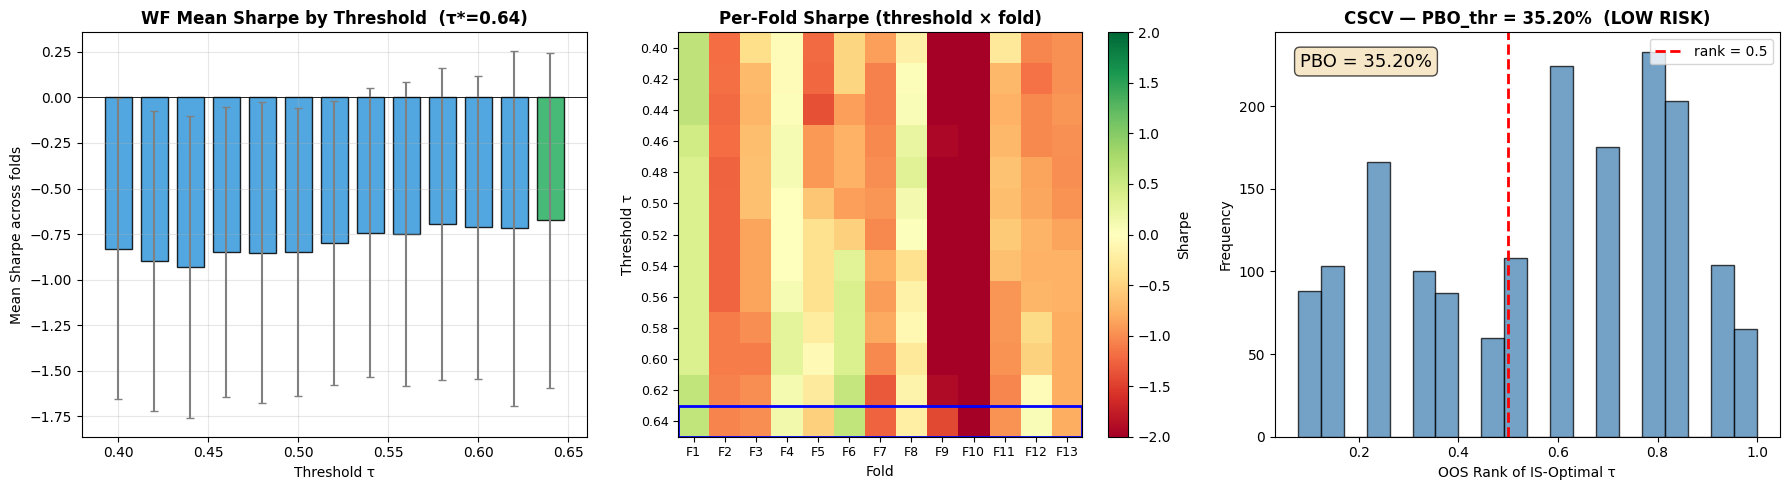


Saved: threshold_calibration.png


In [9]:
# Threshold grid
THR_GRID = np.round(np.arange(0.40, 0.66, 0.02), 2)
MIN_TRADES_PER_FOLD = 5

def _next_bd_after(date_in, idx=close.index):
    pos = idx.searchsorted(date_in, side='right')
    return idx[pos] if pos < len(idx) else None

def trades_from_oof(probs_series, ev_series, threshold):
    """Build trades with next-day OPEN entry."""
    out = []
    for signal_date, prob, ev_t in zip(probs_series.index, probs_series.values, ev_series.values):
        if np.isnan(prob) or prob < threshold:
            continue
        entry_day = _next_bd_after(signal_date)
        if entry_day is None or entry_day not in spy_open.index:
            continue
        ev_t = pd.Timestamp(ev_t) if not pd.isna(ev_t) else None
        if ev_t is None or ev_t not in spy_close.index:
            continue
        p_in  = spy_open.at[entry_day]
        p_out = spy_close.at[ev_t]
        if pd.isna(p_in) or pd.isna(p_out) or p_in == 0:
            continue
        # SHORT: trade return = -(p_out/p_in - 1) (profit when price falls)
        out.append((entry_day, ev_t, -(p_out / p_in - 1)))
    return out

def fold_sharpe(trades, fold_start, fold_end):
    if not trades:
        return np.nan
    dates = close.loc[fold_start:fold_end].index
    spy_daily_local = spy_close.loc[fold_start:fold_end].pct_change().fillna(0)
    daily_sum = pd.Series(0.0, index=dates)
    daily_n   = pd.Series(0,   index=dates)
    for entry_day, exit_t, _ in trades:
        # SHORT — daily contributions are NEGATED (profit when price falls)
        # Entry day: -(open-to-close return)
        if entry_day in dates and entry_day in spy_open.index:
            p_open  = spy_open.at[entry_day]
            p_close = spy_close.at[entry_day]
            if not (pd.isna(p_open) or pd.isna(p_close) or p_open == 0):
                daily_sum.loc[entry_day] += -(p_close / p_open - 1)
                daily_n.loc[entry_day]   += 1
        # Subsequent days: -close-to-close
        span = dates[(dates > entry_day) & (dates <= exit_t)]
        if len(span):
            daily_sum.loc[span] += -spy_daily_local.loc[span].values
            daily_n.loc[span]   += 1
    port = (daily_sum / daily_n.replace(0, np.nan)).fillna(0)
    s = port.std()
    return float(port.mean() / s * np.sqrt(252)) if s > 0 else 0.0

thr_fold_sharpe  = np.full((len(THR_GRID), len(splits)), np.nan)
thr_fold_ntrades = np.full((len(THR_GRID), len(splits)), 0, dtype=int)

for fi, (_, val_idx, vs, ve) in enumerate(splits):
    val_dates = X_is.index[val_idx]
    val_probs = primary_probs_oof.loc[val_dates]
    val_ev    = ev_is.iloc[val_idx]
    for ti, thr in enumerate(THR_GRID):
        trs = trades_from_oof(val_probs, val_ev, thr)
        thr_fold_ntrades[ti, fi] = len(trs)
        if len(trs) < MIN_TRADES_PER_FOLD:
            continue
        thr_fold_sharpe[ti, fi] = fold_sharpe(trs, vs, ve)

thr_mean_sharpe = np.nanmean(thr_fold_sharpe, axis=1)
thr_std_sharpe  = np.nanstd(thr_fold_sharpe, axis=1)
best_idx_thr    = int(np.nanargmax(thr_mean_sharpe))
prim_thr_calibrated = float(THR_GRID[best_idx_thr])

print('=' * 60)
print('PRIMARY THRESHOLD CALIBRATION (WF, OOF-based)')
print('=' * 60)
print(f'  Grid : {THR_GRID.tolist()}')
print(f'  Folds: {len(splits)}')
print(f'\n  τ      mean Sharpe   std    median n trades/fold')
for ti, thr in enumerate(THR_GRID):
    marker = '  ← BEST' if ti == best_idx_thr else ''
    median_nt = int(np.median(thr_fold_ntrades[ti]))
    print(f'  {thr:.2f}   {thr_mean_sharpe[ti]:6.3f}      '
          f'{thr_std_sharpe[ti]:5.3f}  {median_nt:>4d}{marker}')

print(f'\n  τ* (calibrated): {prim_thr_calibrated:.2f}  '
      f'(mean Sharpe = {thr_mean_sharpe[best_idx_thr]:.3f})')

def _compute_pbo_local(score_matrix):
    n_cfg, n_folds = score_matrix.shape
    if n_cfg < 2 or n_folds < 4:
        return np.nan, np.array([])
    S = n_folds
    S_half = S // 2
    combos_l = list(combinations(range(S), S_half))
    oos_ranks = []
    for is_idx in combos_l:
        oos_idx = [i for i in range(S) if i not in is_idx]
        is_sc  = np.nanmean(score_matrix[:, list(is_idx)], axis=1)
        oos_sc = np.nanmean(score_matrix[:, oos_idx], axis=1)
        if np.all(np.isnan(is_sc)) or np.all(np.isnan(oos_sc)):
            continue
        best = int(np.nanargmax(is_sc))
        oos_ranks.append(float(np.mean(oos_sc <= oos_sc[best])))
    oos_ranks = np.array(oos_ranks)
    pbo = float(np.mean(oos_ranks < 0.5)) if len(oos_ranks) else np.nan
    return pbo, oos_ranks

pbo_thr, oos_ranks_thr = _compute_pbo_local(thr_fold_sharpe)
risk_msg = 'HIGH (overfit risk)' if pbo_thr > 0.5 else 'LOW (selection is robust)'
print(f'\n  PBO(threshold selection) = {pbo_thr:.2%}  → {risk_msg}')

if CALIBRATE_PRIM_THRESHOLD:
    PRIM_THRESHOLD = prim_thr_calibrated
    print(f'\n  PRIM_THRESHOLD overridden → {PRIM_THRESHOLD:.2f}')
else:
    print(f'\n  CALIBRATE_PRIM_THRESHOLD=False → keeping manual PRIM_THRESHOLD={PRIM_THRESHOLD:.2f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
colors = ['#27ae60' if i == best_idx_thr else '#3498db' for i in range(len(THR_GRID))]
ax.bar(THR_GRID, thr_mean_sharpe, yerr=thr_std_sharpe, width=0.015,
       color=colors, edgecolor='k', alpha=0.85,
       error_kw=dict(ecolor='gray', capsize=3))
ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel('Threshold τ')
ax.set_ylabel('Mean Sharpe across folds')
ax.set_title(f'WF Mean Sharpe by Threshold  (τ*={prim_thr_calibrated:.2f})',
             fontweight='bold')
ax.grid(True, alpha=0.3)

ax = axes[1]
im = ax.imshow(thr_fold_sharpe, aspect='auto', cmap='RdYlGn', vmin=-2, vmax=2)
ax.set_yticks(range(len(THR_GRID)))
ax.set_yticklabels([f'{t:.2f}' for t in THR_GRID], fontsize=9)
ax.set_xticks(range(len(splits)))
ax.set_xticklabels([f'F{i+1}' for i in range(len(splits))], fontsize=9)
ax.set_ylabel('Threshold τ')
ax.set_xlabel('Fold')
ax.set_title('Per-Fold Sharpe (threshold × fold)', fontweight='bold')
ax.add_patch(plt.Rectangle((-0.5, best_idx_thr - 0.5), len(splits), 1,
                            fill=False, edgecolor='blue', lw=2))
plt.colorbar(im, ax=ax, label='Sharpe')

ax = axes[2]
if len(oos_ranks_thr):
    ax.hist(oos_ranks_thr, bins=20, edgecolor='k', alpha=0.75, color='steelblue')
    ax.axvline(0.5, color='red', ls='--', lw=2, label='rank = 0.5')
    risk_short = 'HIGH RISK' if pbo_thr > 0.5 else 'LOW RISK'
    ax.set_title(f'CSCV — PBO_thr = {pbo_thr:.2%}  ({risk_short})', fontweight='bold')
    ax.set_xlabel('OOS Rank of IS-Optimal τ')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.text(0.05, 0.95, f'PBO = {pbo_thr:.2%}', transform=ax.transAxes,
            fontsize=13, va='top',
            bbox=dict(boxstyle='round', fc='wheat', alpha=0.7))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'threshold_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nSaved: threshold_calibration.png')

## 7. Meta-Labeling Model — López de Prado (AFML Cap. 3)

Modelo secundario que aprende a **filtrar falsos positivos del primario SHORT**:

- **Subset de entrenamiento**: solo filas IS donde `primary_prob_oof >= PRIM_THRESHOLD` (lo que el primario habría comprado)
- **Target**: mismo `y_is` (TP hit). El meta aprende *¿el bet primario fue correcto?*
- **Features**: `X_is + primary_prob_oof` (la prob primaria es señal directa al meta)
- **Weights**: `uniq_w` reutilizada (mismos eventos)
- **Walk-forward purgado**: misma estructura `splits` re-indexada al subset meta
- **Predicción OOS**: aplicar primario sobre X_oos, luego meta sobre [X_oos, probs_oos]
- **Trade rule**: long si `primary_prob >= PRIM_THRESHOLD AND meta_prob >= META_THRESHOLD`

⚠ Importante: el meta se entrena con predicciones **out-of-fold** del primario (almacenadas en `primary_probs_oof`), nunca in-sample → evita leakage.

In [10]:
# ── Build meta dataset (subset where primary OOF fired) ───────────────────────
meta_mask_is = (primary_probs_oof >= PRIM_THRESHOLD).fillna(False)

X_meta = X_is.loc[meta_mask_is].copy()
X_meta['primary_prob'] = primary_probs_oof.loc[meta_mask_is].values
y_meta = y_is.loc[meta_mask_is]
ev_meta = ev_is.loc[meta_mask_is]

w_is_series = pd.Series(w_is, index=X_is.index)
w_meta      = w_is_series.loc[meta_mask_is].values

meta_feature_names = X_meta.columns.tolist()
print(f'Meta dataset: {len(X_meta):,} rows ({len(X_meta)/len(X_is):.1%} of IS)')
print(f'  pos rate (TP within fired set): {y_meta.mean():.1%}  '
      f'(vs {y_is.mean():.1%} on full IS)')
print(f'  features: {len(meta_feature_names)} (X + primary_prob)')

# ── Walk-forward splits on the meta subset ────────────────────────────────────
splits_meta = wf_splits(X_meta.index, ev_meta, VAL_MONTHS, MIN_TRAIN_YEARS, OOS_START)
print(f'\nMeta walk-forward splits: {len(splits_meta)}')

# Meta uses same param strategy as primary
meta_params = {**base_params, **FIXED_OVERRIDE} if SKIP_TUNING else {**base_params, **best_overrides}

X_meta_arr = X_meta.values
y_meta_arr = y_meta.values

meta_fold_scores = []
print(f"\nRunning meta walk-forward ({mode_tag} mode)...")
t_meta = time.time()
for fi, (tr_idx, val_idx, vs, ve) in enumerate(splits_meta):
    if len(tr_idx) < 50 or len(val_idx) < 5:
        print(f'  Fold {fi+1}/{len(splits_meta)}: SKIPPED (tr={len(tr_idx)}, val={len(val_idx)})')
        meta_fold_scores.append(np.nan)
        continue
    t0 = time.time()
    m = ExplainableBoostingClassifier(**meta_params)
    m.fit(X_meta_arr[tr_idx], y_meta_arr[tr_idx], sample_weight=w_meta[tr_idx])
    p = m.predict_proba(X_meta_arr[val_idx])[:, 1]
    score = ap_lift(y_meta_arr[val_idx], p, sample_weight=w_meta[val_idx])
    meta_fold_scores.append(score)
    print(f'  Fold {fi+1:>2}/{len(splits_meta)}  {vs.date()}→{ve.date()}  '
          f'tr={len(tr_idx):>4}  val={len(val_idx):>3}  '
          f'AP-lift={score:.3f}  ({time.time()-t0:.1f}s)')

print(f'\nMeta WF total time: {time.time()-t_meta:.1f}s')
print(f'Meta AP Lift (val mean): {np.nanmean(meta_fold_scores):.4f} '
      f'± {np.nanstd(meta_fold_scores):.4f}')

# ── Final meta model trained on full meta dataset ─────────────────────────────
print('\nTraining final meta EBM on full meta IS dataset...')
final_meta_ebm = ExplainableBoostingClassifier(**meta_params)
final_meta_ebm.fit(X_meta_arr, y_meta_arr, sample_weight=w_meta)

is_meta_ap = ap_lift(y_meta_arr, final_meta_ebm.predict_proba(X_meta_arr)[:, 1],
                     sample_weight=w_meta)
print(f'Meta IS AP Lift (optimistic): {is_meta_ap:.4f}')

# Sanity: leakage proxy
wf_meta_ap = np.nanmean(meta_fold_scores)
gap = is_meta_ap - wf_meta_ap
print(f'Train-vs-WF gap: {gap:+.3f}  '
      f'({"⚠ possible overfit" if gap > 0.3 else "OK"})')

Meta dataset: 1,338 rows (31.4% of IS)
  pos rate (TP within fired set): 38.1%  (vs 40.4% on full IS)
  features: 84 (X + primary_prob)

Meta walk-forward splits: 10

Running meta walk-forward (SKIP_TUNING mode)...
  Fold  1/10  2011-02-04→2012-02-04  tr= 376  val=103  AP-lift=1.092  (0.9s)
  Fold  2/10  2012-02-04→2013-02-04  tr= 482  val= 52  AP-lift=1.145  (1.0s)
  Fold  3/10  2013-02-04→2014-02-04  tr= 534  val= 67  AP-lift=1.243  (1.0s)
  Fold  4/10  2014-02-04→2015-02-04  tr= 601  val=137  AP-lift=0.808  (1.0s)
  Fold  5/10  2015-02-04→2016-02-04  tr= 737  val= 56  AP-lift=1.048  (1.0s)
  Fold  6/10  2016-02-04→2017-02-04  tr= 792  val= 98  AP-lift=0.900  (1.1s)
  Fold  7/10  2017-02-04→2018-02-04  tr= 890  val= 95  AP-lift=1.162  (1.1s)
  Fold  8/10  2018-02-04→2019-02-04  tr= 987  val= 76  AP-lift=0.893  (1.1s)
  Fold  9/10  2019-02-04→2020-02-04  tr=1063  val=104  AP-lift=1.382  (1.2s)
  Fold 10/10  2020-02-04→2021-02-04  tr=1165  val=171  AP-lift=1.117  (1.2s)

Meta WF total 

## 8. Backtest P&L Out-of-Sample (OOS) — SHORT Primary vs SHORT Primary+Meta vs SPY

Entrena un modelo final con `best_params` sobre todo IS y predice **sobre OOS (2022+)**. Compara 3 estrategias en SPY:

1. **Primary only**: SHORT si `probs_oos >= PRIM_THRESHOLD`
2. **Primary + Meta**: SHORT si `probs_oos >= PRIM_THRESHOLD AND meta_probs_oos >= META_THRESHOLD`
3. **SPY Buy & Hold** (benchmark)

- **Entrada**: cierre del día de la señal
- **Salida**: cierre en `event_end` (triple barrier)
- **Tamaño**: equal-weighted (o por `meta_prob` si `SIZE_BY_META=True`)
- **Sharpe**: anualizado (252 días), mostrado en gráfico y anotación

Training final primary EBM on full IS for OOS backtest...
Primary OOS predictions: 1,100 | fired (>= 0.5) = 43.2%
Meta OOS predictions:   confirmed (>= 0.4) = 248/475 (52.2% of primary signals)

Primary trades : 475
Meta trades    : 248

OOS Backtest window: 2022-01-03 → 2026-05-21
Entry: SHORT next-day OPEN  |  Exit: event_end CLOSE
  SHORT Primary only   | Total=-39.80% | CAGR=-10.98% | Vol=12.61% | Sharpe=-0.86 | MaxDD=-44.23%
  SHORT Primary + Meta | Total=-38.12% | CAGR=-10.41% | Vol=10.53% | Sharpe=-0.99 | MaxDD=-41.76%
  SPY Buy & Hold       | Total= 64.81% | CAGR= 12.14% | Vol=17.67% | Sharpe= 0.74 | MaxDD=-24.47%


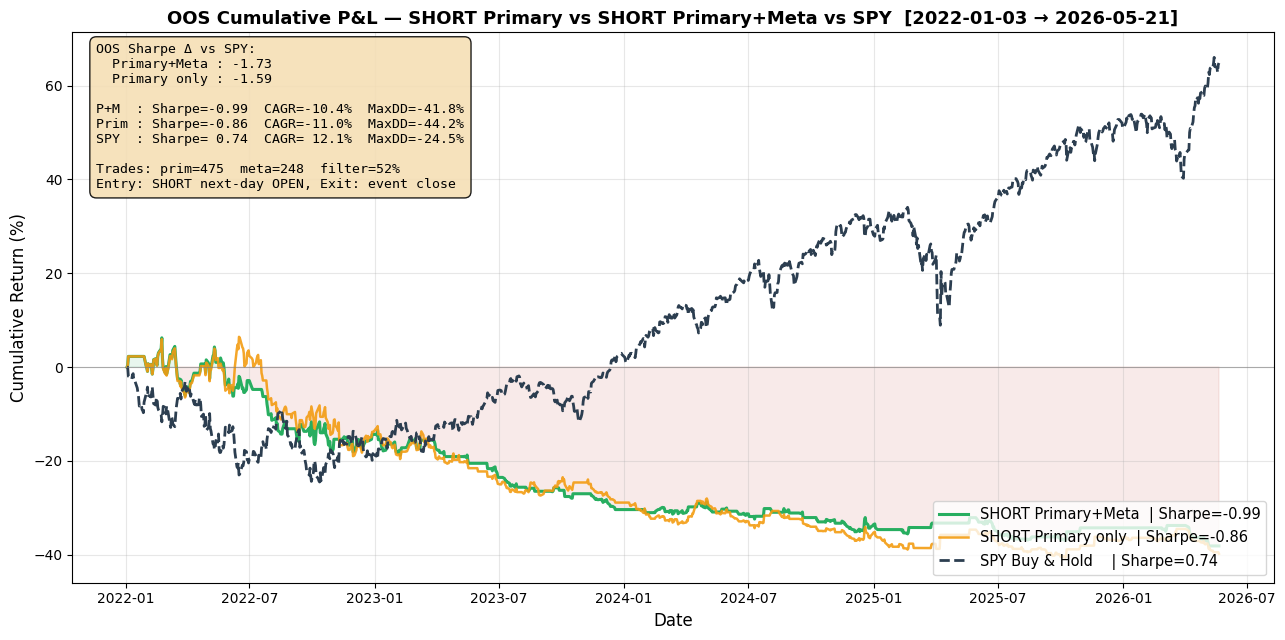

Saved: pnl_short_vs_spy_oos.png


In [11]:
# ── Train final primary model on full IS, predict on OOS ─────────────────────
print('Training final primary EBM on full IS for OOS backtest...')
ebm_oos = ExplainableBoostingClassifier(**best_params)
ebm_oos.fit(X_is.values, y_is.values, sample_weight=w_is)

probs_oos = ebm_oos.predict_proba(X_oos.values)[:, 1]
print(f'Primary OOS predictions: {len(probs_oos):,} | '
      f'fired (>= {PRIM_THRESHOLD}) = {(probs_oos >= PRIM_THRESHOLD).mean():.1%}')

# ── Meta predictions on OOS ──────────────────────────────────────────────────
X_oos_meta = X_oos.copy()
X_oos_meta['primary_prob'] = probs_oos
meta_probs_oos = final_meta_ebm.predict_proba(X_oos_meta.values)[:, 1]

prim_signal = probs_oos      >= PRIM_THRESHOLD
meta_signal = meta_probs_oos >= META_THRESHOLD
combined    = prim_signal & meta_signal

print(f'Meta OOS predictions:   confirmed (>= {META_THRESHOLD}) = '
      f'{combined.sum()}/{prim_signal.sum()} '
      f'({combined.sum()/max(prim_signal.sum(),1):.1%} of primary signals)')


# ── Helper: next business day in close.index ─────────────────────────────────
def next_bd_after(date_in, idx=close.index):
    pos = idx.searchsorted(date_in, side='right')
    return idx[pos] if pos < len(idx) else None


# ── Helper: build trades with next-day OPEN entry ────────────────────────────
def build_trades(signal_mask, sizes):
    """Returns DataFrame: signal_date, entry_day (next BD), exit_day, ret, size.

    Entry price  = spy_open at next BD after signal (real execution)
    Exit price   = spy_close at event_end (triple barrier hit / vertical)
    Return       = exit_close / entry_open - 1
    """
    out = []
    for signal_date, fire, sz, ev_t in zip(X_oos.index, signal_mask, sizes, ev_oos.values):
        if not fire:
            continue
        entry_day = next_bd_after(signal_date)
        if entry_day is None or entry_day not in spy_open.index:
            continue
        ev_t = pd.Timestamp(ev_t) if not pd.isna(ev_t) else None
        if ev_t is None or ev_t not in spy_close.index:
            continue
        p_in  = spy_open.at[entry_day]
        p_out = spy_close.at[ev_t]
        if pd.isna(p_in) or pd.isna(p_out) or p_in == 0:
            continue
        # SHORT: realized return = -(p_out/p_in - 1)
        out.append(dict(signal=signal_date, entry=entry_day, exit=ev_t,
                        ret=-(p_out / p_in - 1), size=float(sz)))
    return pd.DataFrame(out).sort_values('signal').reset_index(drop=True) if out else pd.DataFrame()


sizes_prim = np.ones_like(probs_oos)
sizes_meta = meta_probs_oos if SIZE_BY_META else np.ones_like(meta_probs_oos)

trades_primary = build_trades(prim_signal, sizes_prim)
trades_meta    = build_trades(combined,    sizes_meta)

print(f'\nPrimary trades : {len(trades_primary):,}')
print(f'Meta trades    : {len(trades_meta):,}')


# ── Daily portfolio returns over OOS window ──────────────────────────────────
bt_start = X_oos.index[0]
bt_end   = X_oos.index[-1]
bt_dates = close.loc[bt_start:bt_end].index
spy_daily = spy_close.loc[bt_start:bt_end].pct_change().fillna(0)

def daily_portfolio_returns(trades_df):
    """Daily portfolio return = weighted mean of open positions' daily returns.
    Day-of-entry: open-to-close return; subsequent days: close-to-close.
    """
    if trades_df.empty:
        return pd.Series(0.0, index=bt_dates)
    daily_sum = pd.Series(0.0, index=bt_dates)
    daily_w   = pd.Series(0.0, index=bt_dates)
    for _, t in trades_df.iterrows():
        entry_day = t['entry']
        exit_day  = t['exit']
        sz = t['size']
        # SHORT — daily contributions NEGATED (profit when price falls)
        # Entry day: -(open-to-close)
        if entry_day in bt_dates and entry_day in spy_open.index:
            p_open  = spy_open.at[entry_day]
            p_close = spy_close.at[entry_day]
            if not (pd.isna(p_open) or pd.isna(p_close) or p_open == 0):
                daily_sum.loc[entry_day] += -(p_close / p_open - 1) * sz
                daily_w.loc[entry_day]   += sz
        # Subsequent days: -close-to-close
        span = bt_dates[(bt_dates > entry_day) & (bt_dates <= exit_day)]
        if len(span):
            daily_sum.loc[span] += -spy_daily.loc[span].values * sz
            daily_w.loc[span]   += sz
    return (daily_sum / daily_w.replace(0, np.nan)).fillna(0)

port_daily_ret      = daily_portfolio_returns(trades_primary)
port_daily_ret_meta = daily_portfolio_returns(trades_meta)

strategy_equity      = (1 + port_daily_ret).cumprod() - 1
strategy_equity_meta = (1 + port_daily_ret_meta).cumprod() - 1

# ── SPY benchmark (open-to-open buy-and-hold over OOS) ───────────────────────
spy_open_bt   = spy_open.loc[bt_start:bt_end]
spy_close_bt  = spy_close.loc[bt_start:bt_end]
spy_equity    = spy_close_bt / spy_close_bt.iloc[0] - 1
spy_daily_ret = spy_close_bt.pct_change().dropna()


# ── Performance helpers ──────────────────────────────────────────────────────
def sharpe(daily_ret):
    s = daily_ret.std()
    return float(daily_ret.mean() / s * np.sqrt(252)) if s > 0 else float('nan')

def perf_stats(daily_ret, name):
    total  = float((1 + daily_ret).prod() - 1)
    years  = max(len(daily_ret) / 252, 1e-9)
    cagr   = (1 + total) ** (1 / years) - 1 if total > -1 else float('nan')
    vol    = float(daily_ret.std() * np.sqrt(252))
    sh     = sharpe(daily_ret)
    eq     = (1 + daily_ret).cumprod()
    mdd    = float((eq / eq.cummax() - 1).min())
    print(f'  {name:20s} | Total={total:7.2%} | CAGR={cagr:7.2%} | '
          f'Vol={vol:6.2%} | Sharpe={sh:5.2f} | MaxDD={mdd:7.2%}')
    return dict(total=total, cagr=cagr, vol=vol, sharpe=sh, mdd=mdd)

print(f'\nOOS Backtest window: {bt_start.date()} → {bt_end.date()}')
print(f'Entry: SHORT next-day OPEN  |  Exit: event_end CLOSE')
stats_prim = perf_stats(port_daily_ret,      'SHORT Primary only')
stats_meta = perf_stats(port_daily_ret_meta, 'SHORT Primary + Meta')
stats_spy  = perf_stats(spy_daily_ret,       'SPY Buy & Hold')

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6.5))
ax.plot(strategy_equity_meta.index, strategy_equity_meta.values * 100,
        color='#27ae60', lw=2.2,
        label=f'SHORT Primary+Meta  | Sharpe={stats_meta["sharpe"]:.2f}')
ax.plot(strategy_equity.index, strategy_equity.values * 100,
        color='#f39c12', lw=1.8, alpha=0.9,
        label=f'SHORT Primary only  | Sharpe={stats_prim["sharpe"]:.2f}')
ax.plot(spy_equity.index, spy_equity.values * 100,
        color='#2c3e50', lw=2, ls='--',
        label=f'SPY Buy & Hold    | Sharpe={stats_spy["sharpe"]:.2f}')
ax.axhline(0, color='grey', lw=0.8, alpha=0.6)
ax.fill_between(strategy_equity_meta.index, 0, strategy_equity_meta.values * 100,
                where=strategy_equity_meta.values >= 0, color='#27ae60', alpha=0.10)
ax.fill_between(strategy_equity_meta.index, 0, strategy_equity_meta.values * 100,
                where=strategy_equity_meta.values <  0, color='#c0392b', alpha=0.10)

d_meta = stats_meta['sharpe'] - stats_spy['sharpe']
d_prim = stats_prim['sharpe'] - stats_spy['sharpe']
ann = (f'OOS Sharpe Δ vs SPY:\n'
       f'  Primary+Meta : {d_meta:+.2f}\n'
       f'  Primary only : {d_prim:+.2f}\n\n'
       f'P+M  : Sharpe={stats_meta["sharpe"]:5.2f}  CAGR={stats_meta["cagr"]:6.1%}  MaxDD={stats_meta["mdd"]:6.1%}\n'
       f'Prim : Sharpe={stats_prim["sharpe"]:5.2f}  CAGR={stats_prim["cagr"]:6.1%}  MaxDD={stats_prim["mdd"]:6.1%}\n'
       f'SPY  : Sharpe={stats_spy["sharpe"]:5.2f}  CAGR={stats_spy["cagr"]:6.1%}  MaxDD={stats_spy["mdd"]:6.1%}\n\n'
       f'Trades: prim={len(trades_primary)}  meta={len(trades_meta)}  '
       f'filter={len(trades_meta)/max(len(trades_primary),1):.0%}\n'
       f'Entry: SHORT next-day OPEN, Exit: event close')
ax.text(0.02, 0.98, ann, transform=ax.transAxes, fontsize=9.5, va='top', ha='left',
        family='monospace',
        bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.88, ec='k'))

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return (%)', fontsize=12)
ax.set_title(f'OOS Cumulative P&L — SHORT Primary vs SHORT Primary+Meta vs SPY  '
             f'[{bt_start.date()} → {bt_end.date()}]',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pnl_strategy_vs_spy_oos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pnl_short_vs_spy_oos.png')

## 9. Modelo Final + Probabilidad de Backtest Overfitting (PBO)

In [12]:
# ── Final model trained on full IS with uniqueness weights ────────────────────
print('Training final EBM on full IS data...')
final_ebm = ExplainableBoostingClassifier(**best_params)
final_ebm.fit(X_arr, y_arr, sample_weight=w_arr)

is_ap_lift = ap_lift(y_arr, final_ebm.predict_proba(X_arr)[:, 1], sample_weight=w_arr)
print(f'IS AP Lift (optimistic bias expected): {is_ap_lift:.4f}')

# ── PBO via CSCV (López de Prado) ─────────────────────────────────────────────
def compute_pbo(cfg_fold_scores, n_sub=None):
    """Combinatorially Symmetric Cross-Validation."""
    n_cfg, n_folds = cfg_fold_scores.shape
    S = min(n_folds, n_sub or n_folds)
    scores = cfg_fold_scores[:, :S]

    if n_cfg < 2 or S < 4:
        print(f'Warning: need >= 2 configs and >= 4 sub-periods (got {n_cfg}, {S}).')
        return np.nan, np.array([])

    S_half = S // 2
    combos = list(combinations(range(S), S_half))
    oos_ranks = []

    for is_idx in combos:
        oos_idx = [i for i in range(S) if i not in is_idx]
        is_sc   = np.nanmean(scores[:, list(is_idx)], axis=1)
        oos_sc  = np.nanmean(scores[:, oos_idx], axis=1)

        best     = np.argmax(is_sc)
        oos_rank = float(np.mean(oos_sc <= oos_sc[best]))
        oos_ranks.append(oos_rank)

    oos_ranks = np.array(oos_ranks)
    pbo = float(np.mean(oos_ranks < 0.5))
    return pbo, oos_ranks


pbo, oos_ranks = compute_pbo(config_fold_scores, n_sub=PBO_SUBPERIODS)

print(f"\n{'='*55}")
print(f'Probability of Backtest Overfitting (PBO): {pbo:.4f}')
if not np.isnan(pbo):
    print(f'  Based on {len(oos_ranks)} CSCV combinations')
    risk = 'HIGH RISK (> 50%)' if pbo > 0.5 else 'LOW RISK (<= 50%)'
    print(f'  Assessment: {risk}')
print(f"{'='*55}")

Training final EBM on full IS data...
IS AP Lift (optimistic bias expected): 2.2730

Probability of Backtest Overfitting (PBO): nan


## 9b. PBO de selección de configuración Meta (CSCV, López de Prado)

Hemos elegido `META_THRESHOLD = 0.4` y `SIZE_BY_META = True` mirando el OOS — eso es **selección sobre OOS**, riesgo de overfit. Aplicamos **CSCV** sobre un grid de configuraciones meta para medir la probabilidad de que el "mejor" config en IS sea malo en OOS:

- **Grid**: combinaciones de `META_THRESHOLD ∈ {0.30, 0.35, 0.40, 0.45, 0.50, 0.55}` × `SIZE_BY_META ∈ {False, True}` → 12 configs
- **Métrica por sub-periodo**: Sharpe anualizado dentro de cada uno de N=8 sub-periodos OOS
- **CSCV**: por cada combinación S/2 (IS-folds) escogemos el mejor config, miramos su rank en el complemento (OOS-folds)
- **PBO**: fracción de combinaciones donde el IS-óptimo queda por debajo de la mediana en OOS

> Interpretación: PBO < 0.5 → la selección es robusta. PBO > 0.5 → estás escogiendo por suerte.

PBO META CONFIG SELECTION (CSCV) — 12 configs × 8 sub-periods
  C 1: thr=0.30  size=N  | mean Sharpe (OOS subperiods) = -1.04
  C 2: thr=0.35  size=N  | mean Sharpe (OOS subperiods) = -1.08
  C 3: thr=0.40  size=N  | mean Sharpe (OOS subperiods) = -1.28
  C 4: thr=0.45  size=N  | mean Sharpe (OOS subperiods) = -1.24
  C 5: thr=0.50  size=N  | mean Sharpe (OOS subperiods) = -1.18
  C 6: thr=0.55  size=N  | mean Sharpe (OOS subperiods) = -1.12
  C 7: thr=0.30  size=Y  | mean Sharpe (OOS subperiods) = -1.02 ← best on full OOS
  C 8: thr=0.35  size=Y  | mean Sharpe (OOS subperiods) = -1.07
  C 9: thr=0.40  size=Y  | mean Sharpe (OOS subperiods) = -1.26
  C10: thr=0.45  size=Y  | mean Sharpe (OOS subperiods) = -1.22
  C11: thr=0.50  size=Y  | mean Sharpe (OOS subperiods) = -1.16
  C12: thr=0.55  size=Y  | mean Sharpe (OOS subperiods) = -1.11
Best config: thr=0.30  size=Y | mean Sharpe = -1.02
PBO (selection risk) = 31.43%  ✓ LOW overfit risk
CSCV combinations  : 70


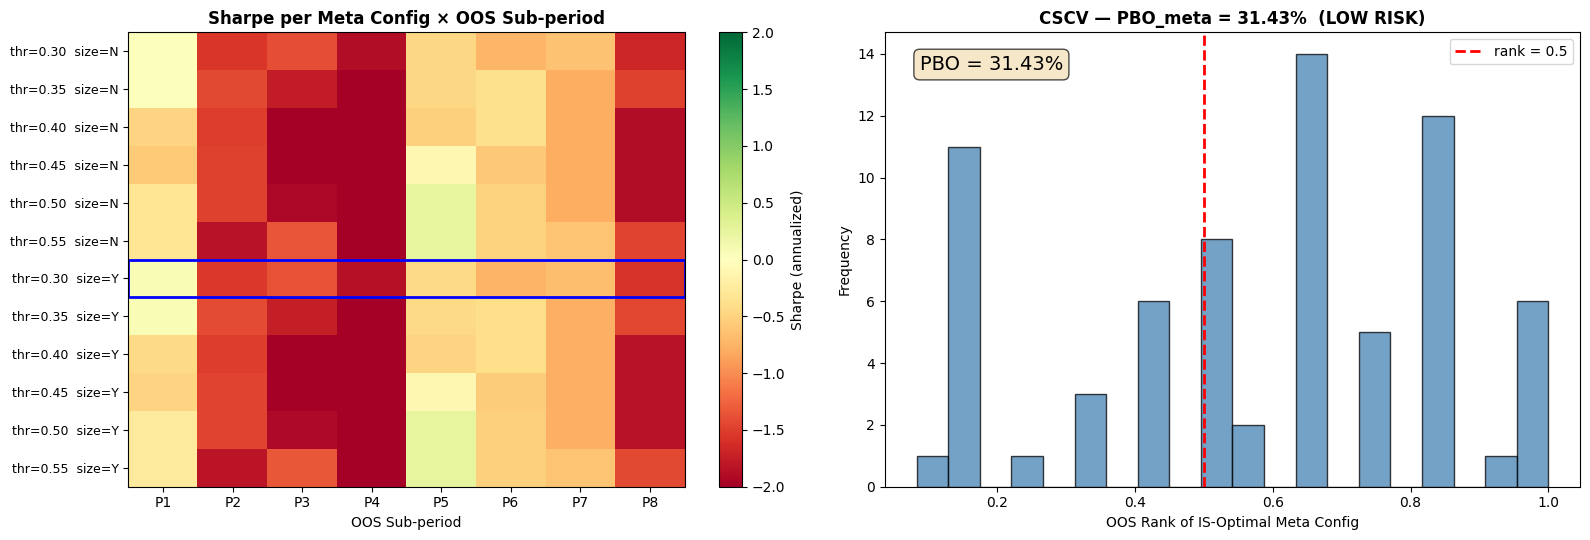

Saved: pbo_meta_selection.png


In [13]:
# ── Grid of meta configurations to evaluate (post-hoc PBO) ────────────────────
META_GRID = [
    dict(thr=0.30, size_by_meta=False),
    dict(thr=0.35, size_by_meta=False),
    dict(thr=0.40, size_by_meta=False),
    dict(thr=0.45, size_by_meta=False),
    dict(thr=0.50, size_by_meta=False),
    dict(thr=0.55, size_by_meta=False),
    dict(thr=0.30, size_by_meta=True),
    dict(thr=0.35, size_by_meta=True),
    dict(thr=0.40, size_by_meta=True),
    dict(thr=0.45, size_by_meta=True),
    dict(thr=0.50, size_by_meta=True),
    dict(thr=0.55, size_by_meta=True),
]
N_SUB_PBO = 8  # OOS sub-periods for CSCV

# ── Build daily-return series per config (reuses build_trades / daily_portfolio_returns) ──
config_daily_rets = []
config_labels     = []
for cfg in META_GRID:
    sig   = prim_signal & (meta_probs_oos >= cfg['thr'])
    sizes = meta_probs_oos if cfg['size_by_meta'] else np.ones_like(meta_probs_oos)
    tr    = build_trades(sig, sizes)
    dr    = daily_portfolio_returns(tr)
    config_daily_rets.append(dr)
    config_labels.append(f"thr={cfg['thr']:.2f}  size={'Y' if cfg['size_by_meta'] else 'N'}")

# ── Sharpe per sub-period ─────────────────────────────────────────────────────
def sharpe_per_subperiod(daily_ret, n_periods):
    n = len(daily_ret) // n_periods
    out = np.full(n_periods, np.nan)
    if n < 5:
        return out
    for i in range(n_periods):
        seg = daily_ret.iloc[i*n:(i+1)*n]
        s = seg.std()
        out[i] = float(seg.mean() / s * np.sqrt(252)) if s > 0 else 0.0
    return out

cfg_period_sharpe = np.array([sharpe_per_subperiod(dr, N_SUB_PBO) for dr in config_daily_rets])

# ── CSCV (reuse compute_pbo from cell-final-pbo) ──────────────────────────────
pbo_meta, oos_ranks_meta = compute_pbo(cfg_period_sharpe, n_sub=N_SUB_PBO)

# ── Best config on full OOS ───────────────────────────────────────────────────
mean_full = np.nanmean(cfg_period_sharpe, axis=1)
best_meta_idx = int(np.nanargmax(mean_full))

print(f'{"="*60}')
print(f'PBO META CONFIG SELECTION (CSCV) — {len(META_GRID)} configs × {N_SUB_PBO} sub-periods')
print(f'{"="*60}')
for i, lbl in enumerate(config_labels):
    marker = ' ← best on full OOS' if i == best_meta_idx else ''
    print(f'  C{i+1:>2}: {lbl}  | mean Sharpe (OOS subperiods) = {mean_full[i]:5.2f}{marker}')
print(f'Best config: {config_labels[best_meta_idx]} | mean Sharpe = {mean_full[best_meta_idx]:.2f}')
print(f'PBO (selection risk) = {pbo_meta:.2%}  '
      f'{"⚠ HIGH overfit risk" if pbo_meta > 0.5 else "✓ LOW overfit risk"}')
print(f'CSCV combinations  : {len(oos_ranks_meta)}')

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# Left: heatmap Sharpe(config × subperiod)
ax = axes[0]
im = ax.imshow(cfg_period_sharpe, aspect='auto', cmap='RdYlGn', vmin=-2, vmax=2)
ax.set_yticks(range(len(META_GRID)))
ax.set_yticklabels(config_labels, fontsize=9)
ax.set_xticks(range(N_SUB_PBO))
ax.set_xticklabels([f'P{i+1}' for i in range(N_SUB_PBO)])
ax.set_xlabel('OOS Sub-period')
ax.set_title('Sharpe per Meta Config × OOS Sub-period', fontweight='bold')
# highlight best row
ax.add_patch(plt.Rectangle((-0.5, best_meta_idx-0.5), N_SUB_PBO, 1,
                            fill=False, edgecolor='blue', lw=2))
plt.colorbar(im, ax=ax, label='Sharpe (annualized)')

# Right: CSCV PBO distribution
ax = axes[1]
if len(oos_ranks_meta) > 0:
    ax.hist(oos_ranks_meta, bins=20, edgecolor='k', alpha=0.75, color='steelblue')
    ax.axvline(0.5, color='red', ls='--', lw=2, label='rank = 0.5')
    ax.set_xlabel('OOS Rank of IS-Optimal Meta Config')
    ax.set_ylabel('Frequency')
    risk = 'HIGH RISK' if pbo_meta > 0.5 else 'LOW RISK'
    ax.set_title(f'CSCV — PBO_meta = {pbo_meta:.2%}  ({risk})', fontweight='bold')
    ax.legend()
    ax.text(0.05, 0.95, f'PBO = {pbo_meta:.2%}', transform=ax.transAxes,
            fontsize=14, va='top',
            bbox=dict(boxstyle='round', fc='wheat', alpha=0.7))
else:
    ax.text(0.5, 0.5, 'Not enough sub-periods for CSCV',
            ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pbo_meta_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: pbo_meta_selection.png')

## 10. Cluster Permutation Importance

In [14]:
def cluster_permutation_importance(
    model, X, y, feat_names, sample_weight=None,
    n_clusters=8, n_repeats=5, random_state=RANDOM_STATE,
):
    """Cluster features by correlation (hierarchical), permute each cluster, measure AP-Lift drop."""
    rng      = np.random.default_rng(random_state)
    baseline = ap_lift(y, model.predict_proba(X)[:, 1], sample_weight=sample_weight)

    corr = np.corrcoef(X.T)
    np.fill_diagonal(corr, 1.0)
    dist = np.sqrt(np.clip((1 - corr) / 2, 0, 1))
    link = linkage(squareform(dist, checks=False), method='ward')
    clust_ids = fcluster(link, n_clusters, criterion='maxclust')

    results = []
    for cid in range(1, n_clusters + 1):
        feat_idx = np.where(clust_ids == cid)[0]
        if len(feat_idx) == 0:
            continue

        perm_scores = []
        for _ in range(n_repeats):
            X_p = X.copy()
            perm = rng.permutation(len(X_p))
            X_p[:, feat_idx] = X_p[:, feat_idx][perm]
            perm_scores.append(
                ap_lift(y, model.predict_proba(X_p)[:, 1], sample_weight=sample_weight)
            )

        top5 = ', '.join(feat_names[i] for i in feat_idx[:5])
        results.append(dict(
            cluster    = cid,
            n_feats    = len(feat_idx),
            importance = baseline - float(np.mean(perm_scores)),
            std        = float(np.std(perm_scores)),
            top_features = top5,
        ))

    imp_df = pd.DataFrame(results).sort_values('importance', ascending=False)
    return imp_df, clust_ids, link, corr


_, val_last, _, _ = splits[-1]
X_val_imp = X_arr[val_last]
y_val_imp = y_arr[val_last]
w_val_imp = w_arr[val_last]

print('Computing cluster permutation importance (last validation fold)...')
imp_df, clust_ids, linkage_mat, corr_mat = cluster_permutation_importance(
    final_ebm, X_val_imp, y_val_imp,
    feat_names=feature_names, sample_weight=w_val_imp,
    n_clusters=8, n_repeats=5,
)

print('\nCluster Permutation Importance:')
print(imp_df[['cluster', 'n_feats', 'importance', 'std', 'top_features']].to_string(index=False))

Computing cluster permutation importance (last validation fold)...

Cluster Permutation Importance:
 cluster  n_feats  importance      std                                                         top_features
       4       22    0.516977 0.061186      XLE_ret_60d, XLB_ret_60d, XLI_ret_60d, XLK_ret_60d, XLF_ret_60d
       8       13    0.399501 0.061701      XLE_ret_20d, XLB_ret_20d, XLI_ret_20d, XLK_ret_20d, XLF_ret_20d
       5       11    0.331848 0.065439 XLE_mom_252d, XLB_mom_252d, XLI_mom_252d, XLK_mom_252d, XLF_mom_252d
       1       15    0.280885 0.042282      XLE_vol_20d, XLB_vol_20d, XLI_vol_20d, XLK_vol_20d, XLF_vol_20d
       6       11    0.277686 0.068441           XLE_ret_5d, XLB_ret_5d, XLI_ret_5d, XLK_ret_5d, XLF_ret_5d
       7        4    0.183937 0.055856   XLB_rs_spy_20d, XLI_rs_spy_20d, XLF_rs_spy_20d, xs_mean_rs_spy_20d
       2        3    0.067058 0.028353                       XLP_rs_spy_20d, XLV_rs_spy_20d, XLU_rs_spy_20d
       3        4    0.039499 0.0162

## 11. Visualizaciones

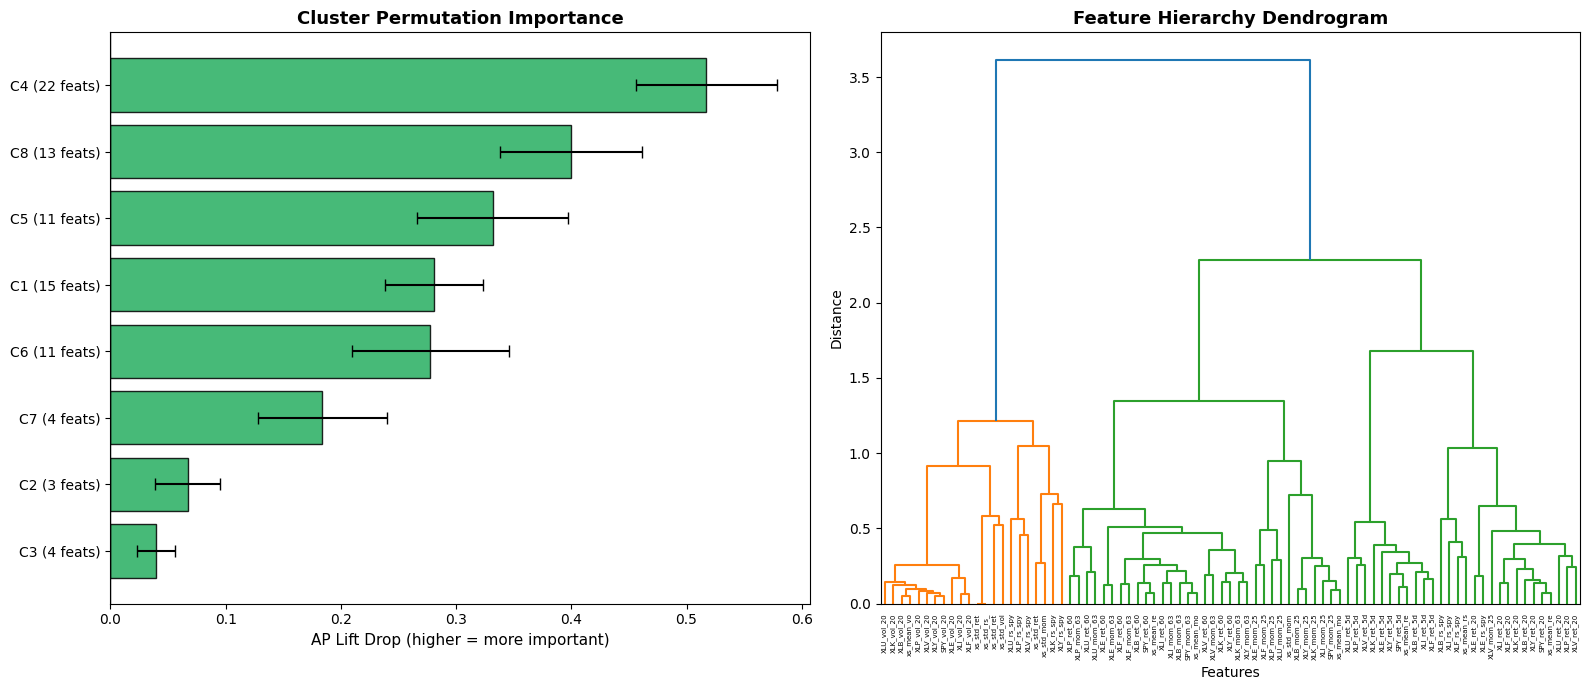

Saved: cluster_permutation_importance.png


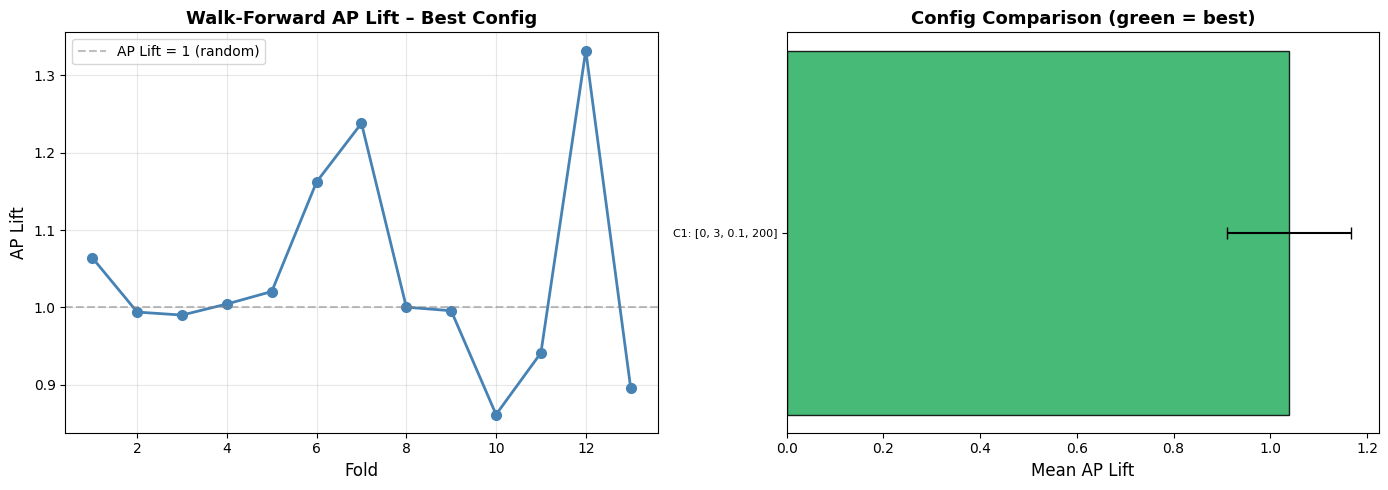

Saved: walkforward_results.png


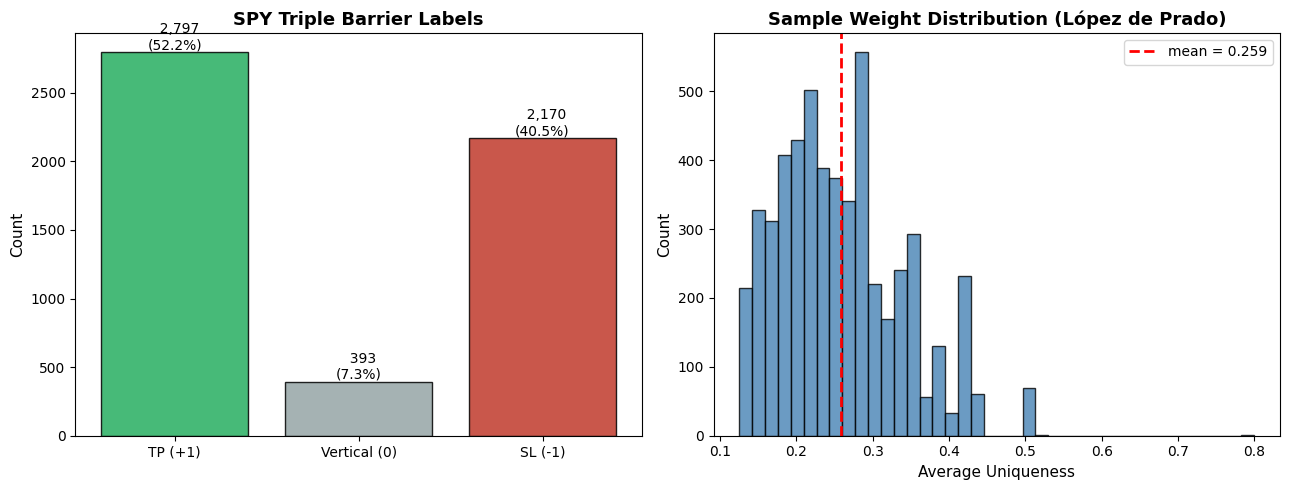

Saved: label_distribution.png


In [15]:
# ── Plot 1: Cluster Permutation Importance + Dendrogram ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
colors_bar = ['#27ae60' if v >= 0 else '#c0392b' for v in imp_df['importance']]
ax.barh(
    range(len(imp_df)), imp_df['importance'],
    xerr=imp_df['std'], color=colors_bar,
    edgecolor='k', alpha=0.85,
    error_kw=dict(ecolor='k', capsize=4),
)
ax.set_yticks(range(len(imp_df)))
ax.set_yticklabels(
    [f"C{r['cluster']} ({r['n_feats']} feats)" for _, r in imp_df.iterrows()],
    fontsize=10,
)
ax.invert_yaxis()
ax.axvline(0, color='k', lw=1)
ax.set_xlabel('AP Lift Drop (higher = more important)', fontsize=11)
ax.set_title('Cluster Permutation Importance', fontsize=13, fontweight='bold')

ax2 = axes[1]
short_names = [f[:10] for f in feature_names]
dendrogram(
    linkage_mat, labels=short_names,
    leaf_rotation=90, leaf_font_size=5, ax=ax2,
    color_threshold=0.7 * linkage_mat[:, 2].max(),
)
ax2.set_title('Feature Hierarchy Dendrogram', fontsize=13, fontweight='bold')
ax2.set_xlabel('Features', fontsize=10)
ax2.set_ylabel('Distance', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cluster_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cluster_permutation_importance.png')

# ── Plot 2: PBO distribution ──────────────────────────────────────────────────
if len(oos_ranks) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(oos_ranks, bins=20, edgecolor='k', alpha=0.7, color='steelblue')
    ax.axvline(0.5, color='red', ls='--', lw=2, label='rank = 0.5')
    ax.set_xlabel('OOS Rank of IS-Optimal Strategy', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'CSCV Distribution  –  PBO = {pbo:.2%}', fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.text(0.05, 0.95, f'PBO = {pbo:.2%}', transform=ax.transAxes,
            fontsize=14, va='top',
            bbox=dict(boxstyle='round', fc='wheat', alpha=0.6))
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'pbo_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: pbo_distribution.png')

# ── Plot 3: Walk-Forward results ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(range(1, len(splits) + 1), config_fold_scores[best_cfg_idx],
        'o-', color='steelblue', lw=2, ms=7)
ax.axhline(1.0, color='grey', ls='--', alpha=0.5, label='AP Lift = 1 (random)')
ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('AP Lift', fontsize=12)
ax.set_title('Walk-Forward AP Lift – Best Config', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
means = np.nanmean(config_fold_scores, axis=1)
stds  = np.nanstd(config_fold_scores, axis=1)
colors_cfg = ['#27ae60' if i == best_cfg_idx else 'steelblue'
              for i in range(len(PARAM_GRID))]
ax.barh(
    range(len(PARAM_GRID)), means, xerr=stds,
    color=colors_cfg, edgecolor='k', alpha=0.85,
    error_kw=dict(ecolor='k', capsize=4),
)
ax.set_yticks(range(len(PARAM_GRID)))
ax.set_yticklabels([f'C{i+1}: {list(p.values())}' for i, p in enumerate(PARAM_GRID)], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Mean AP Lift', fontsize=12)
ax.set_title('Config Comparison (green = best)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'walkforward_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: walkforward_results.png')

# ── Plot 4: SPY label distribution & uniqueness ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
counts = spy_labels.value_counts().reindex([1, 0, -1]).fillna(0).astype(int)
ax.bar(['TP (+1)', 'Vertical (0)', 'SL (-1)'], counts.values,
       color=['#27ae60', '#95a5a6', '#c0392b'], edgecolor='k', alpha=0.85)
for i, v in enumerate(counts.values):
    ax.text(i, v, f'  {v:,}\n({v/counts.sum():.1%})', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('SPY Triple Barrier Labels', fontsize=13, fontweight='bold')

ax = axes[1]
ax.hist(uniq_w.values, bins=40, color='steelblue', edgecolor='k', alpha=0.8)
ax.axvline(uniq_w.mean(), color='red', ls='--', lw=2,
           label=f'mean = {uniq_w.mean():.3f}')
ax.set_xlabel('Average Uniqueness', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Sample Weight Distribution (López de Prado)', fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: label_distribution.png')

## 12. Resumen del Pipeline

In [16]:
sep = '=' * 60
print(sep)
print('PIPELINE SUMMARY — EBM SPY SHORT + Meta-Labeling')
print(sep)
print(f'\nTarget: SPY triple barrier SHORT (SL=+1 vs not-SL)')
print(f'\nData:')
print(f'  Tickers used as features : {ALL_TICKERS}')
print(f'  IS period: {START_DATE} → {OOS_START}')
print(f'  OOS      : {OOS_START} → {END_DATE}  [UNTOUCHED]')
print(f'  IS rows  : {len(X_is):,}')
print(f'  Features : {len(feature_names)}')
print(f'\nTriple Barrier (SPY):')
print(f'  TP = {TP_MULT}x  |  SL = {SL_MULT}x  |  Vol window = {VOL_WINDOW}d  |  Vertical = {VERT_BARS} sessions')
print(f'  IS positive rate (unweighted): {y_is.mean():.1%}')
print(f'  IS positive rate (weighted)  : {np.average(y_is.values, weights=w_is):.1%}')
print(f'\nUniqueness (López de Prado):')
print(f'  Avg uniqueness mean : {uniq_w.mean():.3f}')
print(f'  Concurrent events / bar (mean): {co_ev.mean():.2f}')
print(f'\nWalk-Forward CV (Primary):')
print(f'  Splits    : {len(splits)}')
print(f'  Val window: {VAL_MONTHS} months (expanding train, purging event_end >= val_start)')
print(f'  Best cfg  : {best_overrides}')
print(f'  Best mean AP Lift: {best_mean:.4f}')
print(f'\nMeta-Labeling (López de Prado AFML Cap. 3):')
print(f'  PRIM_THRESHOLD = {PRIM_THRESHOLD}  |  META_THRESHOLD = {META_THRESHOLD}  |  SIZE_BY_META = {SIZE_BY_META}')
print(f'  Meta dataset rows           : {len(X_meta):,} ({len(X_meta)/len(X_is):.1%} of IS)')
print(f'  Meta WF AP Lift (val mean)  : {np.nanmean(meta_fold_scores):.4f}')
print(f'  Meta IS AP Lift (in-sample) : {is_meta_ap:.4f}  (gap={is_meta_ap-np.nanmean(meta_fold_scores):+.3f})')
print(f'\nOOS Backtest:')
print(f'  Primary trades  : {len(trades_primary):,}  | Sharpe={stats_prim["sharpe"]:.2f}')
print(f'  Primary+Meta    : {len(trades_meta):,}  | Sharpe={stats_meta["sharpe"]:.2f}  '
      f'(filter ratio = {len(trades_meta)/max(len(trades_primary),1):.0%})')
print(f'  SPY Buy & Hold  : Sharpe={stats_spy["sharpe"]:.2f}')
print(f'  Sharpe Δ (P+M − SPY) = {stats_meta["sharpe"]-stats_spy["sharpe"]:+.2f}')
print(f'\nBacktest Overfitting (CSCV):')
print(f'  PBO = {pbo:.2%}  ({"HIGH RISK" if pbo > 0.5 else "LOW RISK"})')
print(f'  CSCV combinations: {len(oos_ranks)}')
print(f'\nOutputs → {OUTPUT_DIR}/')
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f'  {f.name}')
print(sep)

PIPELINE SUMMARY — EBM SPY SHORT + Meta-Labeling

Target: SPY triple barrier SHORT (SL=+1 vs not-SL)

Data:
  Tickers used as features : ['XLE', 'XLB', 'XLI', 'XLK', 'XLF', 'XLP', 'XLY', 'XLV', 'XLU', 'SPY']
  IS period: 2005-01-01 → 2022-01-01
  OOS      : 2022-01-01 → 2026-12-31  [UNTOUCHED]
  IS rows  : 4,260
  Features : 83

Triple Barrier (SPY):
  TP = 1.0x  |  SL = 1.0x  |  Vol window = 20d  |  Vertical = 7 sessions
  IS positive rate (unweighted): 40.4%
  IS positive rate (weighted)  : 41.1%

Uniqueness (López de Prado):
  Avg uniqueness mean : 0.259
  Concurrent events / bar (mean): 4.10

Walk-Forward CV (Primary):
  Splits    : 13
  Val window: 12 months (expanding train, purging event_end >= val_start)
  Best cfg  : {'interactions': 0, 'max_leaves': 3, 'learning_rate': 0.1, 'max_rounds': 200}
  Best mean AP Lift: 1.0386

Meta-Labeling (López de Prado AFML Cap. 3):
  PRIM_THRESHOLD = 0.5  |  META_THRESHOLD = 0.4  |  SIZE_BY_META = True
  Meta dataset rows           : 1,338 (31

## 13. Modelo de Producción (entrenado sobre TODO el histórico IS+OOS)

Para deployment práctico — usa el modelo entrenado con **todos los datos disponibles** (no respeta OOS hold-out). El research/validación ya ocurrieron en las secciones anteriores; aquí simplemente "actualizamos" los modelos con la información más reciente.

- `final_prod_ebm`     : EBM primario sobre `X_is + X_oos` completo
- `final_prod_meta_ebm`: EBM meta sobre el subset filtrado (probs OOF para IS, probs ebm_oos para OOS)

⚠ **Trade-off**: estos modelos NO tienen OOS validation propio. La justificación para usarlos en producción se basa en la validación previa de la metodología.

In [17]:
# ── Production primary: train on all available data (IS + OOS) ──────────────
print('Training PRODUCTION primary EBM on full IS+OOS data...')
X_all = pd.concat([X_is, X_oos])
y_all = pd.concat([y_is, y_oos])
w_all = np.concatenate([w_is, w_oos])
ev_all = pd.concat([ev_is, ev_oos])

final_prod_ebm = ExplainableBoostingClassifier(**best_params)
final_prod_ebm.fit(X_all.values, y_all.values, sample_weight=w_all)

# ── Build extended OOF primary probs for meta training ──────────────────────
# IS: primary_probs_oof (true WF OOF predictions)
# OOS: probs_oos (predictions from ebm_oos, which was trained on IS only — still OOF for OOS)
prim_probs_all = pd.concat([
    primary_probs_oof,
    pd.Series(probs_oos, index=X_oos.index),
])
prim_probs_all = prim_probs_all.loc[X_all.index]

# ── Production meta: train on filtered subset of all data ───────────────────
meta_mask_prod = (prim_probs_all >= PRIM_THRESHOLD).fillna(False)
X_meta_prod = X_all.loc[meta_mask_prod].copy()
X_meta_prod['primary_prob'] = prim_probs_all.loc[meta_mask_prod].values
y_meta_prod = y_all.loc[meta_mask_prod]
w_all_series = pd.Series(w_all, index=X_all.index)
w_meta_prod  = w_all_series.loc[meta_mask_prod].values

print(f'Production meta dataset: {len(X_meta_prod):,} rows '
      f'({len(X_meta_prod)/len(X_all):.1%} of full history)')

final_prod_meta_ebm = ExplainableBoostingClassifier(**meta_params)
final_prod_meta_ebm.fit(X_meta_prod.values, y_meta_prod.values, sample_weight=w_meta_prod)

print(f'\n✓ final_prod_ebm      : trained on {len(X_all):,} samples')
print(f'✓ final_prod_meta_ebm : trained on {len(X_meta_prod):,} samples')
print(f'\nLive Signal cell will use these when USE_PRODUCTION_MODEL=True (current: {USE_PRODUCTION_MODEL})')

Training PRODUCTION primary EBM on full IS+OOS data...
Production meta dataset: 1,813 rows (33.8% of full history)

✓ final_prod_ebm      : trained on 5,360 samples
✓ final_prod_meta_ebm : trained on 1,813 samples

Live Signal cell will use these when USE_PRODUCTION_MODEL=True (current: True)


## 14. Live Signal SHORT — Decisión para mañana

Genera la **señal accionable de SHORT** usando los datos más recientes:

- Calculamos primary + meta sobre `X_today` (features al cierre de hoy)
- Si ambos disparan → **SHORT SPY en el OPEN de la próxima sesión**
- **TP** = precio cae a `entry × (1 − σ20d)` → cierras short con beneficio
- **SL** = precio sube a `entry × (1 + σ20d)` → cierras short con pérdida
- TP/SL levels absolutos requieren el precio de entrada — se calculan **una vez tengas el open de mañana**

**Modelo usado:**
- `USE_PRODUCTION_MODEL = True` → `final_prod_ebm` + `final_prod_meta_ebm` (entrenados sobre TODO el histórico — recomendado para producción)
- `USE_PRODUCTION_MODEL = False` → `ebm_oos` + `final_meta_ebm` (entrenados sólo en IS)

**Para refrescar con datos del día actual**: re-ejecuta `cell-data` primero.

LIVE SHORT SIGNAL — signal at close of 2026-06-02
Model: PRODUCTION (trained on full IS+OOS)
  SPY close today  : $759.57
  σ20d (SPY daily) : 0.60%

  Primary prob (SL): 0.084  (threshold 0.50) → no fires ✗
  Meta prob        : 0.084  (threshold 0.40) → VETOES ✗

  ✗ DECISION   : NO TRADE  (primary 0.084 < 0.5; meta 0.084 < 0.4)


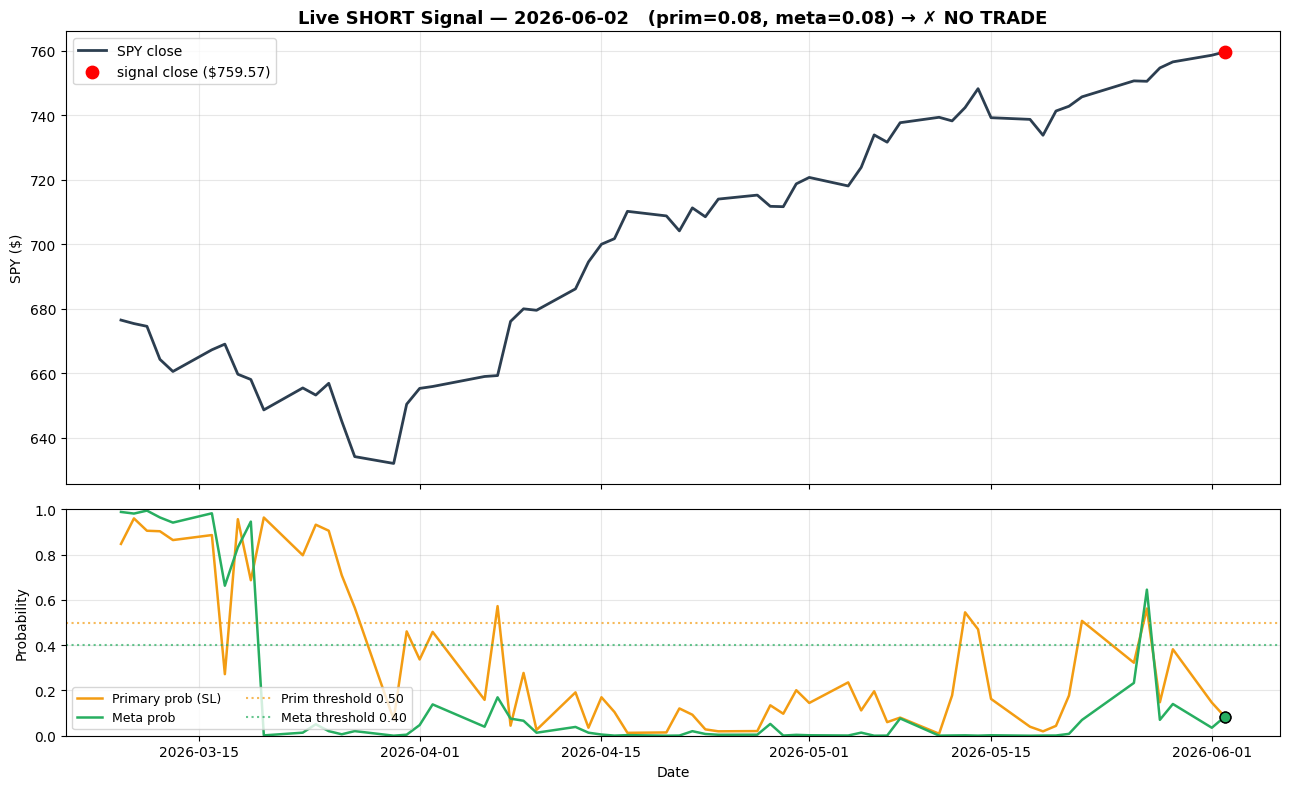

Saved: live_signal_short.png


In [18]:
# Pick model based on flag
if USE_PRODUCTION_MODEL and 'final_prod_ebm' in dir() and 'final_prod_meta_ebm' in dir():
    primary_model = final_prod_ebm
    meta_model    = final_prod_meta_ebm
    model_tag     = 'PRODUCTION (trained on full IS+OOS)'
else:
    primary_model = ebm_oos
    meta_model    = final_meta_ebm
    model_tag     = 'RESEARCH (trained on IS only)'

# Latest available date with non-NaN features
latest_signal_date = X_full.dropna(how='all').index[-1]
X_live = X_full.loc[[latest_signal_date]].fillna(col_medians)

# Primary + Meta predictions (probability of SL hit → short opportunity)
prim_prob_live = float(primary_model.predict_proba(X_live.values)[:, 1][0])
X_live_meta = X_live.copy()
X_live_meta['primary_prob'] = prim_prob_live
meta_prob_live = float(meta_model.predict_proba(X_live_meta.values)[:, 1][0])

primary_fires = prim_prob_live >= PRIM_THRESHOLD
meta_confirms = meta_prob_live >= META_THRESHOLD
decision_short = primary_fires and meta_confirms

# Reference price + 20d vol
spy_close_today = float(spy_close.loc[latest_signal_date])
sigma_20d       = float(spy_vol_roll.loc[latest_signal_date])
tp_pct          = TP_MULT * sigma_20d
sl_pct          = SL_MULT * sigma_20d

# Entry estimate (next BD's open)
all_dates = spy_close.index
next_pos  = all_dates.searchsorted(latest_signal_date, side='right')
if next_pos < len(spy_open.index) and not pd.isna(spy_open.iloc[next_pos]):
    entry_estimate = float(spy_open.iloc[next_pos])
    entry_label = f'OPEN of {spy_open.index[next_pos].date()}'
else:
    entry_estimate = spy_close_today
    entry_label = f'next session OPEN (~ today close ${spy_close_today:,.2f})'

# SHORT TP/SL:
#   TP (profit target) = price falls to entry × (1 - tp_pct)
#   SL (stop loss)     = price rises to entry × (1 + sl_pct)
tp_level_est = entry_estimate * (1 - tp_pct)
sl_level_est = entry_estimate * (1 + sl_pct)
tp_dist_pts  = entry_estimate - tp_level_est
sl_dist_pts  = sl_level_est - entry_estimate

exit_est = latest_signal_date + pd.offsets.BDay(VERT_BARS)

sep = '=' * 64
print(sep)
print(f'LIVE SHORT SIGNAL — signal at close of {latest_signal_date.date()}')
print(f'Model: {model_tag}')
print(sep)
print(f'  SPY close today  : ${spy_close_today:,.2f}')
print(f'  σ20d (SPY daily) : {sigma_20d*100:.2f}%')
print()
print(f'  Primary prob (SL): {prim_prob_live:.3f}  '
      f'(threshold {PRIM_THRESHOLD:.2f}) → '
      f'{"FIRES ✓" if primary_fires else "no fires ✗"}')
print(f'  Meta prob        : {meta_prob_live:.3f}  '
      f'(threshold {META_THRESHOLD:.2f}) → '
      f'{"CONFIRMS ✓" if meta_confirms else "VETOES ✗"}')
print()

if decision_short:
    size_str = f' × {meta_prob_live:.2f}' if SIZE_BY_META else ''
    print(f'  ★★★ DECISION : SHORT SPY at NEXT OPEN ★★★')
    print()
    print(f'  Entry          : {entry_label}{size_str}')
    print(f'  Reference entry: ${entry_estimate:,.2f}')
    print()
    print(f'  TP distance    : -{tp_pct*100:.2f}%   (-${tp_dist_pts:,.2f} per share, price must FALL)')
    print(f'  SL distance    : +{sl_pct*100:.2f}%   (+${sl_dist_pts:,.2f} per share, stop if price RISES)')
    print()
    print(f'  Reference levels (if entry ≈ ${entry_estimate:,.2f}):')
    print(f'    TP level     : ${tp_level_est:,.2f}  (cover for profit)')
    print(f'    SL level     : ${sl_level_est:,.2f}  (cover for loss)')
    print()
    print(f'  Max hold       : {VERT_BARS} sesiones (vertical ≈ {exit_est.date()})')
    print()
    print(f'  → Operational rule once entry fill is known (P_in = actual open):')
    print(f'    TP_level = P_in × {1 - tp_pct:.5f}   (profit cover)')
    print(f'    SL_level = P_in × {1 + sl_pct:.5f}   (stop cover)')
else:
    reason = []
    if not primary_fires:
        reason.append(f'primary {prim_prob_live:.3f} < {PRIM_THRESHOLD}')
    if not meta_confirms:
        reason.append(f'meta {meta_prob_live:.3f} < {META_THRESHOLD}')
    print(f'  ✗ DECISION   : NO TRADE  ({"; ".join(reason)})')
print(sep)

# Visualization
lookback = 60
recent_dates  = spy_close.index[spy_close.index <= latest_signal_date][-lookback:]
recent_prices = spy_close.loc[recent_dates]
recent_X = X_full.loc[recent_dates].fillna(col_medians)
recent_prim = primary_model.predict_proba(recent_X.values)[:, 1]
recent_X_meta = recent_X.copy()
recent_X_meta['primary_prob'] = recent_prim
recent_meta = meta_model.predict_proba(recent_X_meta.values)[:, 1]

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                         gridspec_kw={'height_ratios': [2, 1]})

ax = axes[0]
ax.plot(recent_dates, recent_prices, color='#2c3e50', lw=2, label='SPY close')
ax.scatter([latest_signal_date], [spy_close_today], color='red', s=80, zorder=5,
           label=f'signal close (${spy_close_today:,.2f})')
if decision_short:
    fwd_dates = pd.bdate_range(latest_signal_date, periods=VERT_BARS + 1)
    # For SHORT: TP is BELOW (green = profit zone), SL is ABOVE (red = stop)
    ax.hlines(tp_level_est, latest_signal_date, fwd_dates[-1], colors='#27ae60',
              lw=2, ls='--', label=f'TP est ${tp_level_est:,.2f} (profit cover)')
    ax.hlines(sl_level_est, latest_signal_date, fwd_dates[-1], colors='#c0392b',
              lw=2, ls='--', label=f'SL est ${sl_level_est:,.2f} (stop)')
    ax.axvspan(latest_signal_date, fwd_dates[-1], color='#c0392b', alpha=0.06)
title_decision = '★ SHORT SPY (next open) ★' if decision_short else '✗ NO TRADE'
ax.set_title(f'Live SHORT Signal — {latest_signal_date.date()}   '
             f'(prim={prim_prob_live:.2f}, meta={meta_prob_live:.2f}) → {title_decision}',
             fontsize=13, fontweight='bold')
ax.set_ylabel('SPY ($)')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(recent_dates, recent_prim, color='#f39c12', lw=1.8, label='Primary prob (SL)')
ax.plot(recent_dates, recent_meta, color='#27ae60', lw=1.8, label='Meta prob')
ax.axhline(PRIM_THRESHOLD, color='#f39c12', ls=':', alpha=0.7,
           label=f'Prim threshold {PRIM_THRESHOLD:.2f}')
ax.axhline(META_THRESHOLD, color='#27ae60', ls=':', alpha=0.7,
           label=f'Meta threshold {META_THRESHOLD:.2f}')
ax.scatter([latest_signal_date], [prim_prob_live], color='#f39c12', s=60,
           zorder=5, edgecolor='k')
ax.scatter([latest_signal_date], [meta_prob_live], color='#27ae60', s=60,
           zorder=5, edgecolor='k')
ax.set_ylim(0, 1)
ax.set_ylabel('Probability')
ax.set_xlabel('Date')
ax.legend(loc='lower left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'live_signal_short.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: live_signal_short.png')